# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, math, time, subprocess
import numpy as np, pandas as pd, torch
from IPython.display import display
import torch.nn as nn
import torch.nn.functional as F

MSSV = "2A202602451"
REPO_URL = "https://github.com/SxAinsworth/K4-Track4-Day1-Neuralnetwork.git"   # fork của mình (có code đã push)
IN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")

if IN_COLAB:
    # Kernel Colab (kể cả khi mở từ VS Code) chạy trên máy chủ: lấy code + dữ liệu bằng git,
    # rồi chuyển cwd vào submission_<MSSV>/code để mọi đường dẫn tương đối giống hệt khi chạy local.
    COLAB_REPO = "/content/K4-Track4-Day1-Neuralnetwork"
    if not os.path.isdir(COLAB_REPO):
        subprocess.run(["git", "clone", REPO_URL, COLAB_REPO], check=True)
    else:
        subprocess.run(["git", "-C", COLAB_REPO, "pull", "--rebase"], check=True)
    os.chdir(f"{COLAB_REPO}/submission_{MSSV}/code")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

REPO_ROOT = "../.."     # gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # submission_<MSSV>/: nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

os.makedirs(os.path.join(OUT_DIR, "figures"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "results"), exist_ok=True)

# Kiểm tra trước khi đọc dữ liệu: repo phải chứa data/ và kết quả phải nằm trong thư mục nộp.
repo_root_abs = os.path.abspath(REPO_ROOT)
out_dir_abs = os.path.abspath(OUT_DIR)
print(f"REPO_ROOT -> {repo_root_abs}")
print(f"OUT_DIR   -> {out_dir_abs}")
assert os.path.isdir(os.path.join(repo_root_abs, "data")), "REPO_ROOT không trỏ tới gốc repo có data/."
assert os.path.basename(out_dir_abs) == f"submission_{MSSV}", "OUT_DIR không trỏ tới thư mục nộp."


def push_outputs(msg="Update results from Colab"):
    """Đẩy figures/, results/, xlsx, csv, json từ runtime Colab về GitHub (máy local chỉ cần git pull).
    Cần biến môi trường GH_TOKEN (fine-grained token, quyền Contents: read/write trên repo fork);
    token không được lưu vào notebook."""
    if not IN_COLAB:
        print("Đang chạy local: kết quả đã nằm sẵn trên máy, không cần push.")
        return
    token = os.environ.get("GH_TOKEN")
    if not token:   # không dùng getpass: ô nhập của VS Code dễ bị khuất và làm kernel đứng chờ
        print('Chưa có token: chạy os.environ["GH_TOKEN"] = "github_pat_..." trong một ô tạm '
              '(xoá ô đó trước khi lưu notebook) rồi gọi lại push_outputs().')
        return
    git = ["git", "-C", COLAB_REPO, "-c", "user.name=SxAinsworth",
           "-c", "user.email=SxAinsworth@users.noreply.github.com"]
    subprocess.run(git + ["add", f"submission_{MSSV}"], check=True)
    if subprocess.run(git + ["diff", "--cached", "--quiet"]).returncode == 0:
        print("Không có gì mới để push.")
        return
    subprocess.run(git + ["commit", "-q", "-m", msg], check=True)
    url = REPO_URL.replace("https://", f"https://x-access-token:{token}@")
    for step in (["pull", "--rebase", "-q", url, "main"], ["push", "-q", url, "HEAD:main"]):
        r = subprocess.run(git + step, capture_output=True, text=True)
        if r.returncode != 0:   # in lỗi đã che token, không để token lọt vào output notebook
            print(f"git {step[0]} lỗi (mã {r.returncode}):", (r.stdout + r.stderr).replace(token, "***"))
            return
    print("Đã push. Trên máy local chạy: git pull")


# Tự nạp lại các module .py trước mỗi ô: sau khi git pull code mới, không cần khởi động lại kernel
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except NameError:   # chạy ngoài IPython
    pass
from data import prepare_data, iterate_batches
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

PyTorch: 2.11.0+cu130
Device: cuda
GPU: Tesla T4
REPO_ROOT -> /content/K4-Track4-Day1-Neuralnetwork
OUT_DIR   -> /content/K4-Track4-Day1-Neuralnetwork/submission_2A202602451


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
# Chia train/eval theo metadata (chỉ chạy script nếu chưa có file .npz)
if not os.path.exists(f"{REPO_ROOT}/data/processed/eval.npz"):
    subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)

set_seed(42)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
assert len(data["X_tr"]) == 371_847 and len(data["X_val"]) == 92_962 and len(data["X_eval"]) == 116_203

# Tỉ lệ lớp ở 3 tập phải gần như bằng nhau (phân tầng)
print("\nlớp   train(%)   val(%)   eval(%)")
props = [torch.bincount(data[k], minlength=7).float().cpu() / len(data[k]) * 100 for k in ("y_tr", "y_val", "y_eval")]
for c in range(7):
    print(f"{c:>3d}   {props[0][c]:7.3f}  {props[1][c]:7.3f}  {props[2][c]:7.3f}")

# 10 cột số trên X_tr sau chuẩn hoá: mean ≈ 0, std ≈ 1; 44 cột nhị phân giữ nguyên 0/1
num = data["X_tr"][:, :10]
print("\nmean 10 cột số (X_tr):", np.round(num.mean(0).cpu().numpy(), 4))
print("std  10 cột số (X_tr):", np.round(num.std(0).cpu().numpy(), 4))
print("cột nhị phân chỉ gồm 0/1:", bool(torch.isin(data["X_tr"][:, 10:], torch.tensor([0.0, 1.0], device=device)).all()))

train (371847, 54) | val (92962, 54) | eval (116203, 54)
luôn đoán lớp đa số (1): val acc = 0.4876

lớp   train(%)   val(%)   eval(%)
  0    36.461   36.460   36.460
  1    48.760   48.760   48.760
  2     6.154    6.154    6.154
  3     0.473    0.472    0.472
  4     1.634    1.634    1.634
  5     2.989    2.989    2.989
  6     3.530    3.530    3.530

mean 10 cột số (X_tr): [-0. -0.  0.  0.  0.  0. -0. -0. -0.  0.]
std  10 cột số (X_tr): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
cột nhị phân chỉ gồm 0/1: True


In [3]:
# Kiểu dữ liệu và khoảng nhãn của các tensor dùng chung cho mọi thí nghiệm
for k in ("X_tr", "y_tr", "X_val", "y_val", "X_eval", "y_eval"):
    t = data[k]
    extra_info = f"nhãn {t.min().item()}..{t.max().item()}" if k.startswith("y") else ""
    print(f"{k:<7s} {str(tuple(t.shape)):<12s} {str(t.dtype):<14s} {t.device}  {extra_info}")
assert all(data[k].dtype == torch.float32 and data[k].shape[1] == 54 for k in ("X_tr", "X_val", "X_eval"))
assert all(data[k].dtype == torch.int64 for k in ("y_tr", "y_val", "y_eval"))

# eval_row_id phải gắn đúng thứ tự mẫu eval: đủ 116 203 id, không trùng, và đối chiếu ngẫu nhiên vài dòng với CSV gốc
import pandas as pd
rid = data["eval_row_id"]
assert len(rid) == len(data["X_eval"]) == 116_203 and len(np.unique(rid)) == len(rid)
raw = pd.read_csv(f"{REPO_ROOT}/data/covtype.csv.gz")
check = np.random.default_rng(0).choice(len(rid), size=200, replace=False)
csv_rows = raw.iloc[rid[check]]
X_eval_raw = csv_rows.drop(columns="Cover_Type").to_numpy(np.float32)
X_eval_back = data["X_eval"][check].cpu().numpy().copy()
X_eval_back[:, :10] = X_eval_back[:, :10] * np.where(data["std"] > 0, data["std"], 1) + data["mean"]   # bỏ chuẩn hoá
assert np.allclose(X_eval_back, X_eval_raw, atol=1e-2), "X_eval lệch với CSV theo row_id"
assert (csv_rows["Cover_Type"].to_numpy() - 1 == data["y_eval"][check].cpu().numpy()).all(), "nhãn eval lệch với CSV"
print("eval_row_id: 200 dòng ngẫu nhiên khớp CSV gốc (đặc trưng và nhãn) ✓")
del raw

# iterate_batches: mỗi epoch đi qua MỌI mẫu train đúng một lần; lô cuối nhỏ hơn được giữ lại
sizes, seen = [], []
g = torch.Generator().manual_seed(0)
for xb, yb in iterate_batches(data["X_tr"], data["y_tr"], 512, generator=g):
    sizes.append(len(xb))
print(f"batch 512: {len(sizes)} lô/epoch, lô cuối = {sizes[-1]} mẫu, tổng = {sum(sizes)}")
assert sum(sizes) == len(data["X_tr"]) and sizes[-1] == len(data["X_tr"]) % 512

X_tr    (371847, 54) torch.float32  cuda:0  
y_tr    (371847,)    torch.int64    cuda:0  nhãn 0..6
X_val   (92962, 54)  torch.float32  cuda:0  
y_val   (92962,)     torch.int64    cuda:0  nhãn 0..6
X_eval  (116203, 54) torch.float32  cuda:0  
y_eval  (116203,)    torch.int64    cuda:0  nhãn 0..6
eval_row_id: 200 dòng ngẫu nhiên khớp CSV gốc (đặc trưng và nhãn) ✓
batch 512: 727 lô/epoch, lô cuối = 135 mẫu, tổng = 371847


**Nhận xét Part 0:**
- Kích thước khớp GUIDE: train còn 371 847, val 92 962, eval 116 203. Tỉ lệ lớp ở ba tập gần như trùng nhau nhờ phân tầng. Phép tách val dùng **seed 42 cố định** cho mọi thí nghiệm; khi đổi seed huấn luyện để đo nhiễu, seed tách val vẫn giữ nguyên.
- Mốc "luôn đoán lớp đa số" (lớp 1) trên val = 0,4876: mọi mô hình phải vượt mức này.
- **Vì sao chỉ dùng X_tr để tính mean/std?** Mean/std là tham số của pipeline, cũng "học" từ dữ liệu như trọng số. Nếu tính trên val hoặc eval, thông tin của tập dùng để đánh giá rò rỉ vào bước tiền xử lý, nên điểm val/eval không còn là ước lượng trung thực cho dữ liệu chưa thấy. Áp dụng *cùng* mean/std của train lên val/eval thì được phép (giống khi triển khai: dữ liệu mới chỉ được biến đổi bằng thống kê đã có).
- 44 cột nhị phân (Wilderness_Area, Soil_Type) giữ nguyên 0/1; nếu cột số nào có std = 0 thì chỉ trừ mean (tránh chia cho 0).
- **Lô cuối:** 371 847 = 726 × 512 + 135, nên lô cuối có 135 mẫu. Mình giữ lô này (không `drop_last`) để mỗi epoch dùng hết dữ liệu; nó chỉ chiếm 1/727 số bước nên ảnh hưởng không đáng kể.

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

In [4]:
# 1a–1b. Dựng M-base, kiểm tra số tham số và shape qua từng lớp
set_seed(42)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879, n_params
print(model)
print("số tham số:", n_params)

h = torch.randn(8, 54, device=device)
print(f"\n{'đầu vào':<54s} {tuple(h.shape)}")
for layer in model.net:
    h = layer(h)
    print(f"{str(layer):<54s} {tuple(h.shape)}")
assert h.shape == (8, 7)

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
số tham số: 47879

đầu vào                                                (8, 54)
Linear(in_features=54, out_features=256, bias=True)    (8, 256)
ReLU()                                                 (8, 256)
Linear(in_features=256, out_features=128, bias=True)   (8, 128)
ReLU()                                                 (8, 128)
Linear(in_features=128, out_features=7, bias=True)     (8, 7)


In [5]:
# 1b (tiếp). Kiểm tra cấu trúc, không chỉ shape
linears = [m for m in model.modules() if isinstance(m, nn.Linear)]
assert [(m.in_features, m.out_features) for m in linears] == [(54, 256), (256, 128), (128, 7)]
assert all(m.bias is not None for m in linears), "mọi Linear phải có bias"
assert isinstance(model.net[-1], nn.Linear), "lớp cuối phải là Linear (logit thô, không softmax)"
assert not any(isinstance(m, (nn.Softmax, nn.LogSoftmax, nn.BatchNorm1d, nn.LayerNorm)) for m in model.modules())
print("Linear:", [(m.in_features, m.out_features) for m in linears], "| bias: có ở mọi lớp | không softmax/BatchNorm/LayerNorm")

# Hai kiến trúc tuỳ chọn cũng phải khớp số tham số quy định
for hid in [(512, 256), (256, 128, 64)]:
    n = count_params(MLP(hidden=hid))
    assert n == EXPECTED_PARAMS[hid], (hid, n)
    print(f"MLP{hid}: {n:,} tham số ✓")

# Dropout (khi q > 0) chỉ nằm ngay sau ReLU của lớp ẩn, không ở đầu vào hay trên logit
m_drop = MLP(hidden=(256, 128), dropout=0.3)
kinds = [type(l).__name__ for l in m_drop.net]
print("q = 0.3:", " → ".join(kinds))
assert kinds == ["Linear", "ReLU", "Dropout", "Linear", "ReLU", "Dropout", "Linear"]
assert all(l.p == 0.3 for l in m_drop.net if isinstance(l, nn.Dropout))

# He thực sự được áp dụng: std(W) ≈ sqrt(2/n_in), bias = 0; mặc định của nn.Linear chỉ cho std ≈ 1/sqrt(3·n_in)
for i, m in enumerate(linears, 1):
    print(f"W{i}: std = {m.weight.std().item():.4f} | He kỳ vọng sqrt(2/{m.in_features}) = {math.sqrt(2 / m.in_features):.4f}"
          f" | mặc định nn.Linear ≈ {1 / math.sqrt(3 * m.in_features):.4f} | bias toàn 0: {bool((m.bias == 0).all())}")
    assert abs(m.weight.std().item() / math.sqrt(2 / m.in_features) - 1) < 0.1 and (m.bias == 0).all()

Linear: [(54, 256), (256, 128), (128, 7)] | bias: có ở mọi lớp | không softmax/BatchNorm/LayerNorm
MLP(512, 256): 161,287 tham số ✓
MLP(256, 128, 64): 55,687 tham số ✓
q = 0.3: Linear → ReLU → Dropout → Linear → ReLU → Dropout → Linear
W1: std = 0.1944 | He kỳ vọng sqrt(2/54) = 0.1925 | mặc định nn.Linear ≈ 0.0786 | bias toàn 0: True
W2: std = 0.0881 | He kỳ vọng sqrt(2/256) = 0.0884 | mặc định nn.Linear ≈ 0.0361 | bias toàn 0: True
W3: std = 0.1304 | He kỳ vọng sqrt(2/128) = 0.1250 | mặc định nn.Linear ≈ 0.0510 | bias toàn 0: True


In [6]:
# 1c-1. Loss bước 0 trên toàn bộ val (eval mode, chưa cập nhật bước nào); mốc chẩn đoán ln 7
model.eval()
with torch.no_grad():
    logits0 = model(data["X_val"])
    loss0 = F.cross_entropy(logits0, data["y_val"]).item()
print(f"loss bước 0 trên val = {loss0:.4f}   |   ln 7 = {math.log(7):.4f}   |   chênh = {loss0 - math.log(7):+.4f}")
print("std kích hoạt bước 0 (sau ReLU1, ReLU2, logit):", [round(v, 3) for v in activation_stats(model, data["X_val"][:4096])])

# Chẩn đoán độ lệch: logit có lớn không, và có lệch hệ thống về một lớp không?
print("trung bình logit theo lớp trên val:", np.round(logits0.mean(0).cpu().numpy(), 3))
print("tỉ lệ dự đoán theo lớp ở bước 0:  ", np.round(torch.bincount(logits0.argmax(1), minlength=7).cpu().numpy() / len(logits0), 3))
# Phép thử đối chứng (không đổi baseline): thu nhỏ W3 100 lần thì logit ≈ 0, softmax ≈ đều, loss phải ≈ ln 7
with torch.no_grad():
    z = logits0 - model.net[-1].bias      # bias = 0 nên đây chính là W3·h
    loss_small = F.cross_entropy(z * 0.01, data["y_val"]).item()
print(f"đối chứng: logit × 0.01 -> loss = {loss_small:.4f} (≈ ln 7)")

loss bước 0 trên val = 2.3776   |   ln 7 = 1.9459   |   chênh = +0.4317
std kích hoạt bước 0 (sau ReLU1, ReLU2, logit): [0.414, 0.379, 0.649]
trung bình logit theo lớp trên val: [-0.423 -0.094  0.185 -0.335  0.941  0.073  0.521]
tỉ lệ dự đoán theo lớp ở bước 0:   [0.    0.011 0.098 0.004 0.679 0.011 0.197]
đối chứng: logit × 0.01 -> loss = 1.9482 (≈ ln 7)


loss bước 0 = 2.3702, loss cuối = 1.29e-06, accuracy trên 20 mẫu = 1.00
nhãn của 20 mẫu: [8, 9, 1, 0, 0, 1, 1] | đạt 100% từ bước 5


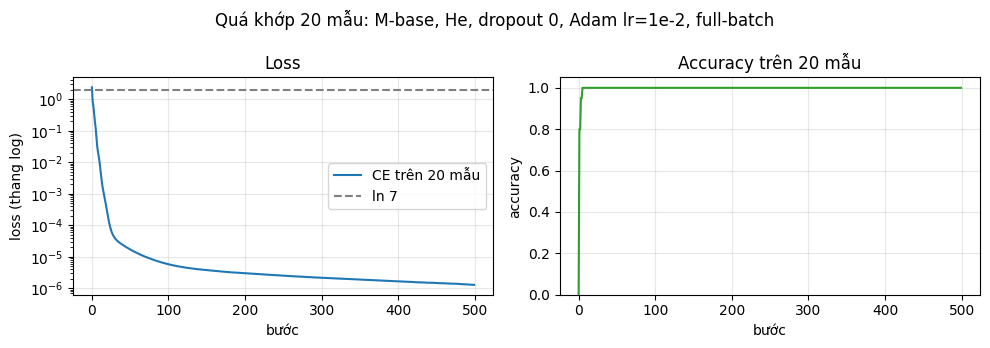

In [7]:
# 1c-2. Quá khớp 20 mẫu: tắt dropout, Adam lr=1e-2, 500 bước full-batch -> loss phải về gần 0
set_seed(42)
tiny = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
idx = torch.randperm(len(data["X_tr"]), generator=torch.Generator().manual_seed(0))[:20].to(device)
xb, yb = data["X_tr"][idx], data["y_tr"][idx]
opt = torch.optim.Adam(tiny.parameters(), lr=1e-2)
tiny_losses, tiny_accs = [], []
for step in range(500):
    tiny.train()
    opt.zero_grad()
    logits = tiny(xb)
    loss = F.cross_entropy(logits, yb)
    loss.backward()
    opt.step()
    tiny_losses.append(loss.item())                                   # loss trước bước cập nhật này
    tiny_accs.append((logits.argmax(1) == yb).float().mean().item())
first100 = next(k for k, a in enumerate(tiny_accs) if a == 1.0)
tiny.eval()
with torch.no_grad():
    acc20 = (tiny(xb).argmax(1) == yb).float().mean().item()
print(f"loss bước 0 = {tiny_losses[0]:.4f}, loss cuối = {tiny_losses[-1]:.2e}, accuracy trên 20 mẫu = {acc20:.2f}")
print("nhãn của 20 mẫu:", torch.bincount(yb, minlength=7).tolist(), f"| đạt 100% từ bước {first100}")
assert tiny_losses[-1] < 1e-2 and acc20 == 1.0

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.semilogy(tiny_losses, label="CE trên 20 mẫu")
ax1.axhline(math.log(7), ls="--", c="gray", label="ln 7")
ax1.set_xlabel("bước"); ax1.set_ylabel("loss (thang log)"); ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(tiny_accs, c="C2")
ax2.set_xlabel("bước"); ax2.set_ylabel("accuracy"); ax2.set_ylim(0, 1.05); ax2.set_title("Accuracy trên 20 mẫu"); ax2.grid(alpha=0.3)
fig.suptitle("Quá khớp 20 mẫu: M-base, He, dropout 0, Adam lr=1e-2, full-batch")
fig.tight_layout()
plt.show()

In [8]:
# 1d. Gradient có chảy tới mọi tham số? (một lần backward trên một lô val, model mới khởi tạo)
model.train()
model.zero_grad()
F.cross_entropy(model(data["X_val"][:512]), data["y_val"][:512]).backward()
names = ["W1", "b1", "W2", "b2", "W3", "b3"]
for name, (pname, p) in zip(names, model.named_parameters()):
    assert p.grad is not None and p.grad.norm().item() > 0, f"{name} không có gradient"
    print(f"{name} ({pname:<12s}) shape {str(tuple(p.shape)):<11s} ‖grad‖ = {p.grad.norm().item():.4e}")
model.zero_grad()

W1 (net.0.weight) shape (256, 54)   ‖grad‖ = 5.7034e-01
b1 (net.0.bias  ) shape (256,)      ‖grad‖ = 3.7935e-01
W2 (net.2.weight) shape (128, 256)  ‖grad‖ = 2.3436e+00
b2 (net.2.bias  ) shape (128,)      ‖grad‖ = 4.9254e-01
W3 (net.4.weight) shape (7, 128)    ‖grad‖ = 2.0775e+00
b3 (net.4.bias  ) shape (7,)        ‖grad‖ = 5.9524e-01


**Nhận xét Part 1:**
- **Cấu trúc:** M-base có đúng 47 879 tham số; ba Linear (54→256, 256→128, 128→7) đều có bias, lớp cuối ra logit thô, không có softmax, BatchNorm hay LayerNorm. Một lô (8, 54) cho logits (8, 7). M-wide (161 287) và M-deep (55 687) cũng khớp bảng. Khi q > 0, Dropout chỉ nằm ngay sau ReLU của hai lớp ẩn.
- **Khởi tạo He đã được áp dụng thật:** std(W) đo được 0,194 / 0,088 / 0,130, khớp sqrt(2/n_in) = 0,193 / 0,088 / 0,125, và khác xa mức mặc định của `nn.Linear` (≈ 0,079 / 0,036 / 0,051). Bias đều bằng 0.
- **Loss bước 0 trên val = 2,378, cao hơn ln 7 = 1,946 khoảng 0,43.** ln 7 chỉ đúng khi mọi logit gần bằng nhau (softmax đều). Với He, lớp cuối cũng có Var(W3) = 2/128, nên logit có std ≈ 0,65 chứ không ≈ 0. Hơn nữa, vì các kích hoạt sau ReLU luôn ≥ 0 và có trung bình dương, W3·h tạo ra một độ lệch **chung cho mọi mẫu** (trung bình logit theo lớp từ −0,42 đến +0,94). Kết quả là ở bước 0 model đoán lớp 4 (Aspen, chỉ 1,6% dữ liệu) cho 68% số mẫu, nên CE cao hơn mức "đoán đều". Phép đối chứng xác nhận nguyên nhân: thu nhỏ logit 100 lần cho loss 1,948 ≈ ln 7. Đây là hệ quả của cách khởi tạo, không phải lỗi dữ liệu hay nhãn (chuẩn hoá đã kiểm tra ở Part 0). Baseline vẫn giữ He theo quy định; chủ đề *khởi tạo* ở Part 3 sẽ so sánh trực tiếp (ví dụ `normal` std 0,01 cho logit gần 0, nên loss bước 0 sẽ ≈ ln 7).
- **Quá khớp 20 mẫu:** với Adam lr = 1e-2, full-batch, dropout 0, accuracy trên 20 mẫu đạt 100% từ bước 5, loss giảm từ 2,37 xuống 1,3e-6 sau 500 bước. Như vậy nhãn, logit → CE, `zero_grad` và danh sách tham số truyền cho optimizer đều đúng. Phép thử này chỉ cho thấy model *đủ năng lực và vòng cập nhật hoạt động*, chưa nói gì về khả năng tổng quát hoá.
- **Gradient:** sau một lần `backward()`, cả 6 tham số W1, b1, W2, b2, W3, b3 đều có gradient khác None và khác 0 (‖grad‖ từ 0,38 đến 2,34), nên không có lớp nào bị "đứt" gradient.

*(Các số trên đo ở seed 42. Nếu chạy trên GPU mà số lẻ cuối lệch chút ít thì cập nhật theo output của ô bên trên.)*

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [9]:
# Hàm dùng chung cho mọi thí nghiệm: chạy -> lưu JSON -> lưu ảnh -> in tóm tắt.
# REUSE_SAVED = True: nếu results/<exp_id>.json đã có (ví dụ sau khi Colab ngắt kết nối) thì nạp lại thay vì chạy lại.
# Kết quả nạp lại KHÔNG có best_state, nên cấu hình dùng cho đánh giá eval cuối cùng luôn được chạy lại (Part 4).
REUSE_SAVED = False
RESULTS = {}

def run(cfg, reuse=None):
    reuse = REUSE_SAVED if reuse is None else reuse
    path = f"{OUT_DIR}/results/{cfg['exp_id']}.json"
    if reuse and os.path.exists(path):
        r = json.load(open(path, encoding="utf-8")); r["best_state"] = None
        tag = "(nạp lại)"
    else:
        t0 = time.time()
        r = run_experiment(cfg, data)
        save_result(r, f"{OUT_DIR}/results")
        plot_run(r, f"{OUT_DIR}/figures/{cfg['exp_id']}.png")
        tag = f"({time.time() - t0:.0f}s)"
    RESULTS[cfg["exp_id"]] = r
    s = r["summary"]
    if s["best_epoch"] is None:
        print(f"{cfg['exp_id']:<22s} DIVERGED ngay epoch {s['epochs_run']} {tag}")
    else:
        print(f"{cfg['exp_id']:<22s} step0 {s['step0_loss']:.3f} | best ep {s['best_epoch']:>2d} | val loss {s['best_val_loss']:.4f}"
              f" | acc {s['val_acc']:.4f} | macro-F1 {s['val_macro_f1']:.4f} | train loss cuối {s['final_train_loss']:.4f}"
              f" | {s['time_per_epoch_s']:.2f}s/ep{' | DIVERGED' if s['diverged'] else ''} {tag}")
    return r

def summary_table(ids):
    rows = []
    for i in ids:
        r = RESULTS[i]; c, s = r["cfg"], r["summary"]
        rows.append({"exp_id": i, "lr": c["lr"], "seed": c["seed"], "best_epoch": s["best_epoch"],
                     "best_val_loss": s["best_val_loss"], "val_acc": s["val_acc"], "val_macro_f1": s["val_macro_f1"],
                     "final_train_loss": s["final_train_loss"], "final_val_loss": s["final_val_loss"],
                     "grad_norm_ep1": r["history"]["grad_norm"][0], "diverged": s["diverged"]})
    return pd.DataFrame(rows).set_index("exp_id").round(4)

### 2a. Dò learning rate cho baseline (chỉ bằng val)
Giữ nguyên mọi yếu tố của baseline (M-base, He, CE, SGD + momentum 0,9, batch 512, 20 epoch, không dropout/clip, FP32, seed 1), **chỉ đổi lr**.
Lưới lr cách nhau khoảng 3 lần và rộng hơn khoảng gợi ý 0,01–0,1 của GUIDE ở cả hai phía, để thấy cả lr quá nhỏ (học chậm) lẫn lr quá lớn (dao động hoặc phân kỳ).
**Quy tắc chọn (đặt trước khi chạy):** chọn lr có **val macro-F1 cao nhất tại best epoch** (chỉ số chính của lab), trong số các lần chạy không phân kỳ.

**Dự đoán trước:** lr = 0,003 học chậm, sau 20 epoch còn xa hội tụ. lr = 0,3 với momentum 0,9 (bước hiệu dụng ≈ lr/(1−μ) = 3) có thể dao động hoặc phân kỳ. lr tốt nhất nằm trong 0,03–0,1, và đường cong vẫn còn đi xuống ở epoch 20 (GUIDE ghi các cấu hình 20 epoch chưa hội tụ hẳn).

In [10]:
LR_GRID = [0.003, 0.01, 0.03, 0.1, 0.3]
lr_ids = []
for lr in LR_GRID:
    exp_id = f"hp-lr{lr:g}"
    run({**DEFAULT_CFG, "exp_id": exp_id, "group": "hparam", "lr": lr, "seed": 1,
         "description": f"Baseline, chỉ đổi lr = {lr:g} (dò lr cho baseline bằng val)"})
    lr_ids.append(exp_id)

lr_table = summary_table(lr_ids)
display(lr_table)
ok = lr_table[~lr_table["diverged"]]
BASE_LR = float(ok["val_macro_f1"].idxmax().removeprefix("hp-lr"))
print(f"\n==> lr chọn cho baseline (val macro-F1 cao nhất): {BASE_LR:g}")
plot_compare([RESULTS[i] for i in lr_ids], ["train_loss", "val_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_lr.png", "Baseline SGD+momentum: dò learning rate (seed 1)")

hp-lr0.003             step0 2.269 | best ep 20 | val loss 0.4198 | acc 0.8250 | macro-F1 0.6647 | train loss cuối 0.4136 | 1.36s/ep (28s)
hp-lr0.01              step0 2.269 | best ep 20 | val loss 0.3110 | acc 0.8747 | macro-F1 0.7613 | train loss cuối 0.2994 | 1.36s/ep (28s)
hp-lr0.03              step0 2.269 | best ep 20 | val loss 0.2660 | acc 0.8921 | macro-F1 0.8170 | train loss cuối 0.2473 | 1.36s/ep (28s)
hp-lr0.1               step0 2.269 | best ep 18 | val loss 0.2379 | acc 0.9054 | macro-F1 0.8390 | train loss cuối 0.2218 | 1.40s/ep (29s)
hp-lr0.3               step0 2.269 | best ep 19 | val loss 0.2318 | acc 0.9090 | macro-F1 0.8573 | train loss cuối 0.2057 | 1.37s/ep (28s)


,lr,seed,best_epoch,best_val_loss,val_acc,val_macro_f1,final_train_loss,final_val_loss,grad_norm_ep1,diverged
exp_id,,,,,,,,,,
hp-lr0.003,0.003,1,20,0.4198,0.8250,0.6647,0.4136,0.4198,0.4266,False
hp-lr0.01,0.010,1,20,0.3110,0.8747,0.7613,0.2994,0.3110,0.4368,False
hp-lr0.03,0.030,1,20,0.2660,0.8921,0.8170,0.2473,0.2660,0.5165,False
hp-lr0.1,0.100,1,18,0.2379,0.9054,0.8390,0.2218,0.2426,0.5296,False
hp-lr0.3,0.300,1,19,0.2318,0.9090,0.8573,0.2057,0.2339,0.3787,False



==> lr chọn cho baseline (val macro-F1 cao nhất): 0.3


### 2b. Baseline với 3 seed: đo độ nhiễu
Cấu hình baseline là `DEFAULT_CFG` với `lr = BASE_LR` vừa chọn. Chạy 3 seed huấn luyện (1, 2, 3); seed thay đổi khởi tạo và thứ tự xáo lô, còn **phép tách val giữ nguyên seed 42**.
`base-s1` trùng cấu hình với lần dò lr tương ứng; chạy lại để kiểm tra tính tái lập (kết quả phải trùng).
Ngưỡng nhiễu theo GUIDE: chênh lệch nhỏ hơn **2σ** (σ là độ lệch chuẩn mẫu giữa các seed) chưa được coi là bằng chứng.

In [11]:
cfg = {**DEFAULT_CFG, "lr": BASE_LR}          # cấu hình baseline; mọi thí nghiệm Part 3 xuất phát từ đây
SEEDS = [1, 2, 3]
base_ids = []
for s in SEEDS:
    run({**cfg, "exp_id": f"base-s{s}", "group": "baseline", "seed": s,
         "description": f"Baseline M-base, SGD+momentum lr={BASE_LR:g}, seed {s}"})
    base_ids.append(f"base-s{s}")

base_table = summary_table(base_ids)
display(base_table)
same = RESULTS["base-s1"]["summary"]["val_macro_f1"] == RESULTS[f"hp-lr{BASE_LR:g}"]["summary"]["val_macro_f1"]
print("base-s1 tái lập đúng lần dò lr cùng cấu hình:", same)

# Độ nhiễu giữa các seed: trung bình ± độ lệch chuẩn mẫu (ddof=1); ngưỡng 2σ dùng cho mọi so sánh ở Part 3
NOISE = {}
for m in ["val_macro_f1", "val_acc", "best_val_loss"]:
    v = base_table[m].astype(float).to_numpy()
    NOISE[m] = {"mean": v.mean(), "std": v.std(ddof=1), "2sigma": 2 * v.std(ddof=1)}
    print(f"{m:<13s}: {v.mean():.4f} ± {v.std(ddof=1):.4f}   (2σ = {2 * v.std(ddof=1):.4f}, min {v.min():.4f}, max {v.max():.4f})")
BASE_F1 = NOISE["val_macro_f1"]["mean"]

plot_compare([RESULTS[i] for i in base_ids], ["train_loss", "val_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_baseline_seeds.png", f"Baseline (lr={BASE_LR:g}): 3 seed")

# Phân bố grad_norm của baseline: cơ sở để chọn ngưỡng clip ở Part 3
gn = np.array([RESULTS[i]["history"]["grad_norm"] for i in base_ids])
gmax = np.array([RESULTS[i]["history"]["grad_norm_max"] for i in base_ids])
print(f"\ngrad_norm baseline: trung bình theo epoch từ {gn.min():.3f} đến {gn.max():.3f}; lớn nhất mọi bước = {gmax.max():.3f}")

base-s1                step0 2.269 | best ep 19 | val loss 0.2318 | acc 0.9090 | macro-F1 0.8573 | train loss cuối 0.2057 | 1.38s/ep (29s)
base-s2                step0 1.978 | best ep 16 | val loss 0.2145 | acc 0.9144 | macro-F1 0.8618 | train loss cuối 0.1964 | 1.35s/ep (28s)
base-s3                step0 1.901 | best ep 18 | val loss 0.2208 | acc 0.9121 | macro-F1 0.8630 | train loss cuối 0.2087 | 1.36s/ep (28s)


,lr,seed,best_epoch,best_val_loss,val_acc,val_macro_f1,final_train_loss,final_val_loss,grad_norm_ep1,diverged
exp_id,,,,,,,,,,
base-s1,0.3,1,19,0.2318,0.9090,0.8573,0.2057,0.2339,0.3787,False
base-s2,0.3,2,16,0.2145,0.9144,0.8618,0.1964,0.2251,0.3800,False
base-s3,0.3,3,18,0.2208,0.9121,0.8630,0.2087,0.2337,0.3760,False


base-s1 tái lập đúng lần dò lr cùng cấu hình: True
val_macro_f1 : 0.8607 ± 0.0030   (2σ = 0.0060, min 0.8573, max 0.8630)
val_acc      : 0.9118 ± 0.0027   (2σ = 0.0054, min 0.9090, max 0.9144)
best_val_loss: 0.2224 ± 0.0088   (2σ = 0.0175, min 0.2145, max 0.2318)

grad_norm baseline: trung bình theo epoch từ 0.332 đến 0.380; lớn nhất mọi bước = 4.141


In [12]:
# Colab: đẩy figures/ và results/ lên GitHub để không mất khi runtime ngắt (máy local: git pull). Bỏ comment khi cần.
# push_outputs("Part 2: dò lr và baseline 3 seed")

**Nhận xét baseline** (số từ lần chạy trên Colab, Tesla T4):
- **lr đã chọn: 0,3** (`hp-lr0.3`, val macro-F1 0,8573 tại best epoch 19). Macro-F1 tăng đều theo lr: 0,003 → 0,6647; 0,01 → 0,7613; 0,03 → 0,8170; 0,1 → 0,8390; 0,3 → 0,8573. Mức tăng từ 0,1 lên 0,3 là 0,018, lớn hơn 2σ_seed = 0,006 (đo ở bên dưới). Tuy vậy, lần dò lr chỉ dùng **một seed**, và khi mình chạy thử trên CPU (khác phần cứng nên khác số lẻ), 0,1 và 0,3 gần như ngang nhau (0,8588 so với 0,8566). Vì thế kết luận chắc chắn được là "lr ≥ 0,1 tốt hơn rõ rệt các lr nhỏ"; còn thứ tự giữa 0,1 và 0,3 chỉ là kết quả của seed 1.
- **lr nhỏ học chậm:** với lr 0,003, sau 20 epoch val loss vẫn còn 0,42 và đang giảm (best epoch 20). Mỗi bước cập nhật ngắn nên 14 540 bước không đủ để đi xa, giống triệu chứng "chưa khớp vì thiếu thời gian" trong bảng chẩn đoán. **Khác dự đoán:** mình đoán lr 0,3 (bước hiệu dụng lr/(1−μ) = 3) sẽ dao động hoặc phân kỳ, nhưng nó không phân kỳ và cho kết quả tốt nhất. Với mạng nhỏ, đầu vào đã chuẩn hoá và ‖g‖ nhỏ (≈ 0,38 ở epoch 1), bước này vẫn nằm trong vùng ổn định. Muốn thấy phân kỳ thật (để làm thí nghiệm clipping) phải tăng lr cao hơn nữa.
- **Hình dạng đường cong** (`figures/base-s1.png`, `compare_baseline_seeds.png`): train loss và val loss giảm nhanh trong vài epoch đầu rồi chậm dần. Best epoch là 16–19 ở cả 3 seed, và val loss cuối luôn cao hơn val loss tốt nhất một chút (`base-s1`: 0,2339 so với 0,2318; `base-s2`: 0,2251 so với 0,2145). Nghĩa là ở cuối, val loss **dao động quanh một mức gần phẳng** chứ không còn giảm đều; đây là nhiễu của SGD với lr lớn và không có lịch giảm lr. Khoảng cách val − train ở epoch 20 khoảng 0,03 (0,2339 so với 0,2057), nhỏ so với mức loss, nên **chưa quá khớp rõ rệt**. Mô hình đang ở gần giới hạn của cấu hình này: giảm lr dần (scheduler) hoặc tăng năng lực mạng có thể còn cải thiện; dropout chưa chắc giúp.
- **So với mốc đoán đa số:** val acc 0,912 so với 0,4876, và val macro-F1 0,861 so với ≈ 0,094. Mô hình học được cả các lớp hiếm chứ không chỉ đoán lớp đông nhất. Macro-F1 thấp hơn accuracy khoảng 0,05 cho thấy các lớp nhỏ (3, 4, 5) vẫn khó hơn (phân tích theo lớp ở Part 4).
- **Độ nhiễu seed** (`base-s1/s2/s3`, cùng phép tách val seed 42): val macro-F1 = **0,8607 ± 0,0030 (2σ = 0,0060)**; val acc = 0,9118 ± 0,0027 (2σ = 0,0054); best val loss = 0,2224 ± 0,0088 (2σ = 0,0175). Ở Part 3, một cấu hình chỉ được coi là khác baseline khi **chênh val macro-F1 > 0,006**. Với chỉ 3 seed, ước lượng σ còn rất thô (bản thân σ có thể sai lệch vài chục phần trăm), nên các chênh lệch sát ngưỡng sẽ được nêu là "chưa kết luận được". `base-s1` cho đúng kết quả của `hp-lr0.3`, nên pipeline tái lập được khi giữ nguyên seed.
- **grad_norm** của baseline (trước clip): trung bình theo epoch ổn định trong khoảng **0,33–0,38**, nhưng bước lớn nhất có gai tới **4,14**. Như vậy phần lớn các bước có ‖g‖ < 1, chỉ vài bước nhảy vọt. Ngưỡng c = 1,0 sẽ chỉ cắt các gai này, còn c ≈ 0,3 sẽ cắt khoảng một nửa số bước. Đây là cơ sở để chọn c ở Part 3. *Quan sát thêm (chưa kiểm chứng):* lr 0,3 có ‖g‖ ở epoch 1 nhỏ hơn lr 0,03–0,1 (0,38 so với ~0,52); một giả thuyết là lr lớn đưa mô hình sang vùng loss phẳng hơn.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố so với baseline → chạy → **đối chiếu**. Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

**Quy ước chung**
- Baseline: `cfg` ở Part 2 (M-base, He, CE, SGD + momentum 0,9, **lr = 0,3**, batch 512, 20 epoch, không dropout/clip, FP32). Mọi thí nghiệm dùng **seed 1**, cùng phép tách val (seed 42), cùng 20 epoch; trừ chính yếu tố đang thử.
- Khi phải đổi thêm yếu tố (ví dụ đổi lr cho phù hợp loss/optimizer mới), lý do ghi trong `notes` của cấu hình (và trong bảng xlsx).
- So sánh bằng **val macro-F1 tại best epoch**, Δ tính so với **trung bình 3 seed baseline** (giống công thức của bảng xlsx). Chênh lệch chỉ được coi là có thật khi |Δ| > **2σ_seed = 0,006**; ngoài ra xem thêm val loss, tốc độ hội tụ (`compare_*.png`), khoảng cách val − train, grad_norm.
- Mọi thí nghiệm chạy 1 seed, nên Δ của từng thí nghiệm cũng mang nhiễu cỡ σ; các Δ sát ngưỡng sẽ được nêu là chưa kết luận được.

In [18]:
STEPS_PER_EPOCH = {b: math.ceil(len(data["X_tr"]) / b) for b in (128, 512, 2048)}
F1_2SIGMA = NOISE["val_macro_f1"]["2sigma"]

def E(exp_id, group, description, notes="", **changes):
    """Cấu hình thí nghiệm = baseline + các thay đổi (seed 1 trừ khi đổi)."""
    return {**cfg, "seed": 1, "exp_id": exp_id, "group": group, "description": description, "notes": notes, **changes}

def compare_table(ids):
    rows = []
    for i in ids:
        r = RESULTS[i]; c, s, h = r["cfg"], r["summary"], r["history"]
        f1 = s["val_macro_f1"]
        d = None if f1 is None else f1 - BASE_F1
        rows.append({
            "exp_id": i, "best_ep": s["best_epoch"], "best_val_loss": s["best_val_loss"],
            "val_acc": s["val_acc"], "val_F1": f1, "ΔF1_vs_base": d,
            "vượt_2σ": "—" if d is None else ("Có" if abs(d) > F1_2SIGMA else "Không"),
            "val−train_cuối": (s["final_val_loss"] - s["final_train_loss"]) if s["final_val_loss"] is not None else None,
            "g_tb": float(np.nanmean(h["grad_norm"])), "g_max": float(np.nanmax(h["grad_norm_max"])),
            "clip_%": 100 * float(np.mean(h["clip_frac"])), "s/ep": s["time_per_epoch_s"],
            "số_bước": s["epochs_run"] * STEPS_PER_EPOCH.get(c["batch"], math.ceil(len(data["X_tr"]) / c["batch"])),
            "peak_MB": s["peak_mem_MB"], "diverged": s["diverged"]})
    df = pd.DataFrame(rows).set_index("exp_id")
    display(df.round(4))
    return df

print(f"baseline: val macro-F1 = {BASE_F1:.4f} (trung bình 3 seed), 2σ = {F1_2SIGMA:.4f}")

baseline: val macro-F1 = 0.8607 (trung bình 3 seed), 2σ = 0.0060


### 3.1 Hàm mất mát — `loss-mse-lr0.3`, `loss-mse-lr1`
**Câu hỏi:** thay cross-entropy bằng MSE giữa logit và one-hot (đúng `nn.MSELoss` mặc định: không có 1/2, trung bình trên B·7 phần tử) thì mô hình học tốt hay kém hơn?

**Dự đoán trước:** MSE sẽ **kém hơn rõ** về macro-F1 (Δ âm, vượt 2σ). Lý do:
1. Gradient của MSE theo logit là 2(z − onehot)/(B·7). Hệ số 1/7 làm gradient nhỏ hơn CE nhiều lần, nên cùng lr = 0,3 MSE học chậm hơn.
2. MSE "phạt" cả việc logit của lớp đúng vượt quá 1, và coi 7 đầu ra như 7 bài hồi quy độc lập. Nó không có cơ chế của softmax-CE, nơi gradient (p − y) luôn đẩy lớp đúng lên và các lớp sai xuống cho tới khi dự đoán đúng. Với lớp hiếm, mô hình dễ kéo logit về gần 0 cho mọi mẫu, nên recall của lớp hiếm thấp và macro-F1 tụt mạnh hơn accuracy.

Chạy thêm lr = 1,0 để bù phần gradient nhỏ (so sánh ở lr tốt hơn của MSE, ghi rõ trong `notes`). Hai loss khác thang đo nên **không so giá trị loss**, chỉ so accuracy, macro-F1 và tốc độ tăng macro-F1 theo epoch.

In [19]:
loss_ids = []
for lr in [0.3, 1.0]:
    e = E(f"loss-mse-lr{lr:g}", "loss", f"MSE (logit vs one-hot, mean trên B·7) thay CE, lr={lr:g}",
          notes="" if lr == 0.3 else "đổi thêm lr=1.0 vì gradient MSE nhỏ hơn CE ~7 lần; so ở lr tốt nhất của MSE",
          loss="mse", lr=lr)
    run(e); loss_ids.append(e["exp_id"])
compare_table(["base-s1"] + loss_ids)
plot_compare([RESULTS[i] for i in ["base-s1"] + loss_ids], ["val_acc", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_loss.png", "CE (base-s1) vs MSE — so bằng metric, không so loss")

loss-mse-lr0.3         step0 0.636 | best ep 20 | val loss 0.0274 | acc 0.8803 | macro-F1 0.7726 | train loss cuối 0.0264 | 1.40s/ep (29s)
loss-mse-lr1           step0 0.636 | best ep 20 | val loss 0.0454 | acc 0.7956 | macro-F1 0.5991 | train loss cuối 0.0452 | 1.47s/ep (30s)


,best_ep,best_val_loss,val_acc,val_F1,ΔF1_vs_base,vượt_2σ,val−train_cuối,g_tb,g_max,clip_%,s/ep,số_bước,peak_MB,diverged
exp_id,,,,,,,,,,,,,,
base-s1,19,0.2318,0.9090,0.8573,-0.0034,Không,0.0282,0.3521,2.8437,0.0,1.3775,14540,208.6680,False
loss-mse-lr0.3,20,0.0274,0.8803,0.7726,-0.0881,Có,0.0010,0.0662,2.2593,0.0,1.3950,14540,208.6714,False
loss-mse-lr1,20,0.0454,0.7956,0.5991,-0.2616,Có,0.0002,0.0402,14.1954,0.0,1.4714,14540,208.6714,False


**Đối chiếu 3.1:**
- **Khớp dự đoán chính: MSE kém CE rõ rệt.** Ở lr tốt hơn của MSE (`loss-mse-lr0.3`), val macro-F1 = 0,7726 so với trung bình baseline 0,8607: Δ = −0,088, gấp ~15 lần 2σ = 0,006, nên khác biệt có thật. Accuracy chỉ giảm 0,029 (0,8803 so với 0,9090 của `base-s1`) trong khi macro-F1 giảm 0,085, tức phần lớn thiệt hại rơi vào **các lớp hiếm**, đúng như dự đoán. MSE coi 7 logit là 7 bài hồi quy độc lập, nên với lớp hiếm, cách "rẻ" nhất để giảm loss là kéo logit của lớp đó về gần 0 ở mọi mẫu. Với CE, gradient (p − y) luôn đẩy lớp đúng lên cho tới khi nó thắng các lớp còn lại.
- **Gradient nhỏ hơn, hội tụ chậm hơn:** ‖g‖ trung bình của MSE chỉ 0,066 so với 0,352 của CE (nhỏ hơn ~5 lần), phù hợp với hệ số 2/(B·7) của MSE so với (p − y)/B của CE. Cả hai lần chạy MSE đều có best epoch = 20 (val loss còn giảm ở epoch cuối), trong khi CE đạt best ở epoch 19. Cùng 14 540 bước, MSE đi được ít hơn.
- **Khác dự đoán:** mình đoán tăng lr lên 1,0 sẽ bù được phần gradient nhỏ, nhưng `loss-mse-lr1` còn **tệ hơn nhiều** (macro-F1 0,5991, acc 0,7956) và có gai ‖g‖ = 14,2 (lr 0,3 chỉ 2,26). *Giả thuyết (chưa kiểm chứng riêng):* ở đầu huấn luyện logit lệch xa one-hot nên gradient MSE không nhỏ; một bước lr = 1 với momentum 0,9 đẩy trọng số đi quá xa và làm nhiều ReLU "chết", giống hiện tượng ở mục 3.5. Vậy trong 2 lr đã thử, lr tốt nhất của MSE là 0,3. **Hạn chế:** chưa thử lr < 0,3 cho MSE, nên "CE tốt hơn MSE" chỉ được khẳng định ở lr tốt nhất *trong các lr đã thử*.
- **Không so giá trị loss:** val loss của MSE (0,027) và CE (0,232) khác thang đo. Khoảng cách val − train của MSE gần 0 (0,001), cho thấy MSE đang chưa khớp chứ không phải quá khớp.
- Thời gian mỗi epoch (~1,4 s) và bộ nhớ đỉnh như nhau: đổi loss không đổi khối lượng tính toán.

### 3.2 Bộ tối ưu hoá — `opt-sgd-*`, `opt-adam-*`, `opt-adamw-*` (SGD + momentum lấy từ `hp-lr*` ở Part 2)
**Câu hỏi:** ở **lr tốt nhất của mỗi bộ**, SGD, SGD + momentum, Adam, AdamW khác nhau thế nào về chất lượng và tốc độ hội tụ?

Cấu hình: SGD không momentum; SGD + momentum μ = 0,9 (5 lr ở Part 2); Adam và AdamW với betas = (0,9; 0,999), eps = 1e-8; Adam weight_decay = 0; AdamW weight_decay = 0,01. Mỗi bộ thử ≥ 2 lr cách nhau ~3 lần: SGD {0,3; 1; 3} (không momentum thì bước hiệu dụng nhỏ hơn 10 lần so với momentum 0,9, nên cần lr lớn hơn); Adam {3e-4; 1e-3; 3e-3}; AdamW {1e-3; 3e-3}.

**Dự đoán trước:**
- Adam/AdamW tăng macro-F1 **nhanh hơn ở vài epoch đầu**, vì bước được chia theo √v̂ của từng tham số nên các trọng số ít khi nhận gradient (cột one-hot hiếm của Soil_Type) vẫn được cập nhật đủ lớn.
- Sau 20 epoch, ở lr tốt nhất, khoảng cách giữa các bộ sẽ nhỏ (có thể dưới 2σ).
- SGD thuần ở lr = 0,3 kém hơn SGD + momentum ở lr = 0,3, nhưng ở lr = 3 (bước hiệu dụng gần bằng SGDM lr 0,3) sẽ gần bằng.
- AdamW với wd = 0,01 gần như bằng Adam: tổng mức co trọng số chỉ khoảng lr·λ·số bước = 1e-3·0,01·14 540 ≈ 0,15.

In [20]:
OPT_GRID = {"sgd": [0.3, 1.0, 3.0], "adam": [3e-4, 1e-3, 3e-3], "adamw": [1e-3, 3e-3]}
opt_ids = {"sgd_momentum": lr_ids}                       # SGD + momentum: 5 lr đã chạy ở Part 2
for name, lrs in OPT_GRID.items():
    opt_ids[name] = []
    for lr in lrs:
        wd = 0.01 if name == "adamw" else 0.0
        e = E(f"opt-{name}-lr{lr:g}", "optimizer", f"{name} thay SGD+momentum, lr={lr:g}, wd={wd:g}",
              notes={"sgd": "momentum=0", "adam": "betas=(0.9,0.999), eps=1e-8, wd=0",
                     "adamw": "betas=(0.9,0.999), eps=1e-8, wd=0.01 (tách riêng)"}[name],
              optimizer=name, lr=lr, weight_decay=wd)
        run(e); opt_ids[name].append(e["exp_id"])

all_opt = [i for ids in opt_ids.values() for i in ids]
df_opt = compare_table(all_opt)
best_per_opt = {name: df_opt.loc[ids, "val_F1"].astype(float).idxmax() for name, ids in opt_ids.items()}
print("lr tốt nhất của mỗi bộ tối ưu (theo val macro-F1):", best_per_opt)
plot_compare([RESULTS[i] for i in best_per_opt.values()], ["train_loss", "val_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_optimizer.png", "Bộ tối ưu ở lr tốt nhất của mỗi bộ (seed 1)")

opt-sgd-lr0.3          step0 2.269 | best ep 18 | val loss 0.2803 | acc 0.8871 | macro-F1 0.8163 | train loss cuối 0.3196 | 1.30s/ep (27s)
opt-sgd-lr1            step0 2.269 | best ep 18 | val loss 0.2522 | acc 0.9000 | macro-F1 0.8344 | train loss cuối 0.2759 | 1.33s/ep (28s)
opt-sgd-lr3            step0 2.269 | best ep 18 | val loss 0.3698 | acc 0.8511 | macro-F1 0.6155 | train loss cuối 0.3518 | 1.30s/ep (27s)
opt-adam-lr0.0003      step0 2.269 | best ep 20 | val loss 0.3135 | acc 0.8727 | macro-F1 0.7877 | train loss cuối 0.3031 | 1.47s/ep (30s)
opt-adam-lr0.001       step0 2.269 | best ep 19 | val loss 0.2494 | acc 0.8993 | macro-F1 0.8456 | train loss cuối 0.2326 | 1.51s/ep (31s)
opt-adam-lr0.003       step0 2.269 | best ep 19 | val loss 0.2145 | acc 0.9153 | macro-F1 0.8677 | train loss cuối 0.1870 | 1.50s/ep (31s)
opt-adamw-lr0.001      step0 2.269 | best ep 20 | val loss 0.2507 | acc 0.9004 | macro-F1 0.8482 | train loss cuối 0.2319 | 1.53s/ep (32s)
opt-adamw-lr0.003      step

,best_ep,best_val_loss,val_acc,val_F1,ΔF1_vs_base,vượt_2σ,val−train_cuối,g_tb,g_max,clip_%,s/ep,số_bước,peak_MB,diverged
exp_id,,,,,,,,,,,,,,
hp-lr0.003,20,0.4198,0.8250,0.6647,-0.1960,Có,0.0062,0.6399,2.9038,0.0,1.3783,14540,177.5918,False
hp-lr0.01,20,0.3110,0.8747,0.7613,-0.0994,Có,0.0115,1.0580,3.8061,0.0,1.3504,14540,177.5918,False
hp-lr0.03,20,0.2660,0.8921,0.8170,-0.0437,Có,0.0187,0.9358,2.8437,0.0,1.3583,14540,177.5918,False
hp-lr0.1,18,0.2379,0.9054,0.8390,-0.0217,Có,0.0207,0.5666,2.8437,0.0,1.3667,14540,177.5918,False
hp-lr0.3,19,0.2318,0.9090,0.8573,-0.0034,Không,0.0282,0.3521,2.8437,0.0,1.3354,14540,177.5918,False
opt-sgd-lr0.3,18,0.2803,0.8871,0.8163,-0.0444,Có,0.0131,0.6714,2.8437,0.0,1.2964,14540,177.4087,False
opt-sgd-lr1,18,0.2522,0.9000,0.8344,-0.0263,Có,0.0246,0.4546,7.0076,0.0,1.3278,14540,177.4087,False
opt-sgd-lr3,18,0.3698,0.8511,0.6155,-0.2452,Có,0.0187,0.3141,31.1138,0.0,1.3030,14540,177.4087,False
opt-adam-lr0.0003,20,0.3135,0.8727,0.7877,-0.0730,Có,0.0104,0.7788,2.8437,0.0,1.4694,14540,177.7749,False


lr tốt nhất của mỗi bộ tối ưu (theo val macro-F1): {'sgd_momentum': 'hp-lr0.3', 'sgd': 'opt-sgd-lr1', 'adam': 'opt-adam-lr0.003', 'adamw': 'opt-adamw-lr0.003'}


**Đối chiếu 3.2:**

| bộ tối ưu | lr đã thử | lr tốt nhất | val macro-F1 | ΔF1 so với baseline | val loss |
|---|---|---|---|---|---|
| SGD + momentum 0,9 | 0,003 … 0,3 | 0,3 (`hp-lr0.3` = `base-s1`) | 0,8573 | −0,003 | 0,2318 |
| SGD (μ = 0) | 0,3; 1; 3 | 1 (`opt-sgd-lr1`) | 0,8344 | −0,026 | 0,2522 |
| Adam | 3e-4; 1e-3; 3e-3 | 3e-3 (`opt-adam-lr0.003`) | 0,8677 | +0,007 | 0,2145 |
| AdamW (wd 0,01) | 1e-3; 3e-3 | 3e-3 (`opt-adamw-lr0.003`) | 0,8646 | +0,004 | 0,2161 |

- **So ở lr tốt nhất của mỗi bộ:** Adam cao hơn baseline +0,007, chỉ vừa vượt 2σ = 0,006, và đây là **một seed**. Bản thân Δ cũng có nhiễu cỡ σ ≈ 0,003, nên mình xếp kết quả này là **"có thể tốt hơn chút ít, chưa chắc chắn"**. Val loss của Adam (0,2145) thấp hơn `base-s1` (0,2318) khoảng 0,017, sát ngưỡng 2σ của val loss (0,0175). AdamW +0,004 nằm trong nhiễu. **Adam và AdamW không phân biệt được** (chênh 0,003 < 2σ), khớp dự đoán về kết quả. Tuy vậy, con số "≈ 0,15" trong dự đoán là cho lr 1e-3; ở lr 3e-3, nếu không có gradient thì riêng phần suy giảm sẽ nhân trọng số với (1 − lr·λ)^số bước ≈ e^(−0,44) ≈ 0,65 sau 14 540 bước, tức không hề nhỏ. Trên thực tế gradient liên tục kéo trọng số về vùng cần thiết, nên hiệu ứng đo được (chênh 0,003) nằm trong nhiễu. Muốn thấy rõ tác dụng của weight decay cần một mô hình đang quá khớp, mà baseline thì không.
- **SGD thuần kém SGD + momentum rõ rệt** (−0,026 ở lr tốt nhất, vượt 2σ), khớp dự đoán. Momentum cộng dồn gradient của ~1/(1−μ) = 10 bước nên đi nhanh hơn theo hướng ổn định và triệt tiêu dao động ngang.
- **Khác dự đoán:** mình đoán SGD ở lr = 3 (bước hiệu dụng bằng SGDM lr 0,3) sẽ gần bằng SGDM, nhưng `opt-sgd-lr3` chỉ đạt 0,6155 và có gai ‖g‖ = 31. *Giải thích (giả thuyết):* với SGD thuần, một gai gradient được nhân nguyên lr = 3 ngay trong **một bước**. Với momentum, cùng gai đó được rải ra trên ~10 bước sau (mỗi bước chỉ lr·g = 0,3·g), nên các gradient kế tiếp kịp "kéo lại" trước khi trọng số đi quá xa. Bước hiệu dụng trung bình như nhau không có nghĩa là bước lớn nhất như nhau.
- **Hạn chế quan trọng:** lr tốt nhất của Adam, AdamW (3e-3) và SGDM (0,3) đều nằm **ở biên lưới đã thử**, nên chưa chắc đó là tối ưu thật của mỗi bộ. Thứ tự giữa các bộ tối ưu có thể đổi khi mở rộng lưới.
- Tốc độ hội tụ ở các epoch đầu: xem `compare_optimizer.png`. Thời gian mỗi epoch của Adam/AdamW lớn hơn SGD ~15% (1,47–1,54 s so với 1,30–1,33 s), do phải cập nhật thêm m và v; bộ nhớ thêm không đáng kể (+0,2 MB cho 2 × 47 879 số).

### 3.3 Hyper-parameter — batch size, độ rộng, độ sâu, số epoch, lịch lr
(Dò lr của baseline ở Part 2 cũng thuộc chủ đề này: `hp-lr*`, ảnh `compare_lr.png`.)

**a) Batch size** — `hp-batch128`, `hp-batch2048`, `hp-batch2048-lr1.2`. Cùng 20 epoch nhưng **số bước cập nhật khác nhau**: 128 → 2 906 bước/epoch, 512 → 727, 2048 → 182.
*Dự đoán:* batch 128 (gấp 4 lần số bước, gradient nhiễu hơn) cho val loss thấp hơn hoặc ngang baseline nhưng **chậm hơn ~3–4 lần mỗi epoch**. Batch 2048 với cùng lr chỉ có 1/4 số bước nên **kém hơn rõ** (chưa khớp). Theo quy tắc tỉ lệ tuyến tính (lô ×4 thì lr ×4 = 1,2), số bước bù lại được phần nào. Nhưng lr = 1,2 mà không có khởi động (warm-up) có thể gây gai gradient ở đầu, giống phép thử lr = 1 ở mục clipping, nên kết quả khó đoán. (`hp-batch2048-lr1.2` đổi 2 yếu tố, đã ghi trong notes.)

**b) Kiến trúc** — `hp-wide` (M-wide 54→512→256→7, 161 287 tham số), `hp-deep` (M-deep 54→256→128→64→7, 55 687 tham số).
*Dự đoán:* baseline đang **chưa khớp** (val − train nhỏ, val loss còn giảm), nên tăng năng lực sẽ giúp: M-wide tốt hơn baseline vượt 2σ; M-deep tăng ít hơn (chỉ thêm 7 808 tham số).

**c) Số epoch / lịch lr** — `hp-ep40` (40 epoch), `hp-cosine` (lr giảm theo cosin từ 0,3 về 0 trong 20 epoch).
*Dự đoán:* 40 epoch tốt hơn vì đường cong 20 epoch chưa phẳng hẳn. Cosine giảm biên độ dao động của val loss ở cuối (đã thấy ở baseline) nên cho val loss thấp hơn mà không tốn thêm bước.

In [21]:
hp_runs = [
    E("hp-batch128", "hparam", "batch 128 thay 512 (cùng lr, 4x số bước)", batch=128),
    E("hp-batch2048", "hparam", "batch 2048 thay 512 (cùng lr, 1/4 số bước)", batch=2048),
    E("hp-batch2048-lr1.2", "hparam", "batch 2048 và lr x4 = 1.2 (quy tắc tỉ lệ tuyến tính, không warm-up)",
      notes="đổi 2 yếu tố: batch và lr (theo quy tắc lô xk thì lr xk)", batch=2048, lr=1.2),
    E("hp-wide", "hparam", "M-wide 54-512-256-7 (161 287 tham số)", hidden=(512, 256)),
    E("hp-deep", "hparam", "M-deep 54-256-128-64-7 (55 687 tham số)", hidden=(256, 128, 64)),
    E("hp-ep40", "hparam", "40 epoch thay 20", epochs=40),
    E("hp-cosine", "hparam", "lịch lr cosine từ 0.3 về 0 trong 20 epoch",
      notes="scheduler=cosine (CosineAnnealingLR, cập nhật mỗi bước, eta_min=0)", scheduler="cosine"),
]
for e in hp_runs:
    run(e)
hp_ids = [e["exp_id"] for e in hp_runs]
compare_table(["base-s1"] + hp_ids)
plot_compare([RESULTS[i] for i in ["base-s1", "hp-batch128", "hp-batch2048", "hp-batch2048-lr1.2"]],
             ["train_loss", "val_loss", "val_macro_f1", "epoch_time_s"], f"{OUT_DIR}/figures/compare_batch.png",
             "Batch size (cùng 20 epoch => số bước khác nhau)")
plot_compare([RESULTS[i] for i in ["base-s1", "hp-wide", "hp-deep"]], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_arch.png", "Độ rộng / độ sâu")
plot_compare([RESULTS[i] for i in ["base-s1", "hp-ep40", "hp-cosine"]], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_schedule.png", "Số epoch và lịch lr")

hp-batch128            step0 2.269 | best ep 14 | val loss 0.3209 | acc 0.8749 | macro-F1 0.7951 | train loss cuối 0.3044 | 5.26s/ep (106s)
hp-batch2048           step0 2.269 | best ep 18 | val loss 0.2437 | acc 0.9014 | macro-F1 0.8338 | train loss cuối 0.2268 | 0.35s/ep (9s)
hp-batch2048-lr1.2     step0 2.269 | best ep 11 | val loss 1.2052 | acc 0.4876 | macro-F1 0.0936 | train loss cuối 1.2036 | 0.36s/ep (8s)
hp-wide                step0 1.918 | best ep 20 | val loss 0.1998 | acc 0.9226 | macro-F1 0.8747 | train loss cuối 0.1669 | 1.43s/ep (30s)
hp-deep                step0 1.910 | best ep 20 | val loss 0.2222 | acc 0.9138 | macro-F1 0.8413 | train loss cuối 0.1913 | 1.51s/ep (31s)
hp-ep40                step0 2.269 | best ep 32 | val loss 0.1995 | acc 0.9232 | macro-F1 0.8733 | train loss cuối 0.1722 | 1.36s/ep (56s)
hp-cosine              step0 2.269 | best ep 20 | val loss 0.1651 | acc 0.9367 | macro-F1 0.8947 | train loss cuối 0.1345 | 1.37s/ep (28s)


,best_ep,best_val_loss,val_acc,val_F1,ΔF1_vs_base,vượt_2σ,val−train_cuối,g_tb,g_max,clip_%,s/ep,số_bước,peak_MB,diverged
exp_id,,,,,,,,,,,,,,
base-s1,19,0.2318,0.9090,0.8573,-0.0034,Không,0.0282,0.3521,2.8437,0.0,1.3775,14540,208.6680,False
hp-batch128,14,0.3209,0.8749,0.7951,-0.0656,Có,0.0200,0.4410,5.6386,0.0,5.2584,58120,208.6372,False
hp-batch2048,18,0.2437,0.9014,0.8338,-0.0269,Có,0.0193,0.4328,2.8469,0.0,0.3493,3640,208.9141,False
hp-batch2048-lr1.2,11,1.2052,0.4876,0.0936,-0.7671,Có,0.0017,0.0368,14.7683,0.0,0.3554,3640,208.9141,False
hp-wide,20,0.1998,0.9226,0.8747,0.0140,Có,0.0328,0.3430,7.0511,0.0,1.4255,14540,225.6455,False
hp-deep,20,0.2222,0.9138,0.8413,-0.0194,Có,0.0309,0.3743,4.1859,0.0,1.5057,14540,208.7588,False
hp-ep40,32,0.1995,0.9232,0.8733,0.0126,Có,0.0357,0.3419,2.8437,0.0,1.3609,29080,208.6680,False
hp-cosine,20,0.1651,0.9367,0.8947,0.0340,Có,0.0306,0.3690,2.8437,0.0,1.3674,14540,208.6680,False


**Đối chiếu 3.3:**

**a) Batch size** (cùng 20 epoch, số bước khác nhau):

| exp_id | batch | lr | số bước | s/epoch | val macro-F1 | ΔF1 |
|---|---|---|---|---|---|---|
| `hp-batch128` | 128 | 0,3 | 58 120 | 5,26 | 0,7951 | −0,066 |
| `base-s1` | 512 | 0,3 | 14 540 | 1,38 | 0,8573 | −0,003 |
| `hp-batch2048` | 2048 | 0,3 | 3 640 | 0,35 | 0,8338 | −0,027 |
| `hp-batch2048-lr1.2` | 2048 | 1,2 | 3 640 | 0,36 | 0,0936 | −0,767 |

- **Khác dự đoán (batch 128):** mình đoán gấp 4 lần số bước sẽ cho kết quả bằng hoặc tốt hơn, nhưng thực tế kém rõ (−0,066) và best epoch rơi vào epoch 14. Cơ chế hợp lý: độ nhiễu của SGD tỉ lệ với lr/B. Giữ lr = 0,3 mà giảm B đi 4 lần thì nhiễu gradient tăng ~4 lần, mô hình dao động quanh vùng loss cao hơn (gai ‖g‖ = 5,6 so với 2,8). Theo quy tắc tỉ lệ tuyến tính, batch 128 phải đi với lr ≈ 0,075; mình chưa chạy để kiểm chứng. Thời gian mỗi epoch tăng 3,8 lần, khớp dự đoán (số bước ×4, mỗi bước gần như cùng chi phí vì GPU chưa bão hoà).
- **Batch 2048, cùng lr:** kém hơn (−0,027, vượt 2σ), khớp dự đoán vì chỉ còn 1/4 số bước. Mức giảm nhỏ hơn mình nghĩ, vì gradient của lô lớn ít nhiễu hơn nên mỗi bước "đáng giá" hơn. Bù lại, mỗi epoch nhanh hơn 3,9 lần (cả lần chạy chỉ 9 s).
- **Quy tắc tỉ lệ tuyến tính không có warm-up thất bại:** `hp-batch2048-lr1.2` sụp về **luôn đoán lớp đa số** (acc 0,4876, macro-F1 0,0936). Gai ‖g‖ = 14,8 ở đầu, sau đó ‖g‖ trung bình chỉ 0,037, nghĩa là gần như mọi ReLU đã "chết" nên gradient không còn chảy. `diverged = False` vì loss không phải NaN, nhưng mạng đã hỏng. Điều này khớp với cảnh báo trong slide: quy tắc ×k cần đi kèm khởi động lr.

**b) Kiến trúc:**
- **M-wide tốt hơn baseline** (`hp-wide`: 0,8747, Δ = +0,014 > 2σ; val loss 0,1998 so với 0,2318), khớp dự đoán "baseline đang chưa khớp, thêm năng lực thì giúp". Train loss giảm mạnh hơn (0,167 so với 0,206), còn khoảng cách val − train chỉ tăng nhẹ (0,033 so với 0,028). Thời gian mỗi epoch chỉ tăng ~4% (1,43 so với 1,38 s) dù số tham số gấp 3,4 lần: với mạng nhỏ, GPU chưa được dùng hết và chi phí bị chi phối bởi số lần gọi kernel. Bộ nhớ đỉnh tăng 17 MB (225,6 so với 208,7).
- **Khác dự đoán (M-deep):** macro-F1 *giảm* (0,8413, Δ = −0,019 > 2σ), dù val loss (0,2222) thấp hơn `base-s1` và train loss cũng thấp hơn. Val loss tốt hơn mà macro-F1 kém hơn cho thấy mô hình khớp tốt hơn ở các lớp lớn nhưng kém hơn ở một vài lớp hiếm, và macro-F1 rất nhạy với các lớp này (lớp 3 chỉ ~440 mẫu val). Một seed không đủ để biết đây là hiệu ứng thật hay nhiễu, nên mình **không kết luận** độ sâu làm hại.

**c) Số epoch và lịch lr:**
- **40 epoch** (`hp-ep40`): +0,013 (> 2σ), val loss 0,1995. Best epoch là 32: sau epoch 32 val loss không giảm nữa trong khi khoảng cách val − train tăng lên 0,036, tức bắt đầu dao động hoặc quá khớp nhẹ. Đúng như dự đoán: 20 epoch chưa đủ.
- **Cosine** (`hp-cosine`): **cải thiện lớn nhất trong toàn bộ Part 3**: macro-F1 0,8947 (Δ = +0,034, gấp ~6 lần 2σ), val loss 0,1651, acc 0,9367, mà vẫn đúng 20 epoch, cùng số bước, cùng thời gian. Khớp dự đoán về hướng, nhưng mức tăng lớn hơn mình nghĩ, lớn hơn cả việc tăng gấp đôi số epoch. Cơ chế: với lr cố định 0,3, SGD dừng ở một "mức nhiễu sàn" tỉ lệ với lr (val loss dao động ở cuối, xem `base-s1.png`). Khi lr giảm dần về 0 ở các epoch cuối, bước nhỏ lại nên mô hình đi xuống được đáy của vùng đang đứng thay vì nhảy quanh nó.

### 3.4 Dropout — `drop-0.1`, `drop-0.3`
**Câu hỏi:** dropout có giúp khi mô hình **chưa quá khớp** không? Ở baseline, val − train loss ở epoch 20 chỉ khoảng 0,03 và best epoch rơi vào 16–19, tức chưa có dấu hiệu quá khớp rõ.

**Dự đoán trước:** dropout là "thuốc" cho quá khớp, mà baseline thì đang chưa khớp, nên dropout sẽ **không giúp, thậm chí làm kém đi**: q = 0,1 xấp xỉ baseline (|Δ| < 2σ), q = 0,3 kém hơn vượt 2σ. Khoảng cách val − train (đo ở eval mode) sẽ nhỏ lại hoặc âm, vì dropout cản mô hình khớp dữ liệu train. Train loss ở eval mode sẽ cao hơn baseline, tức đúng là chưa khớp, chứ không phải chỉ do lúc huấn luyện bị tắt nơ-ron.

In [22]:
drop_ids = []
for q in [0.1, 0.3]:
    e = E(f"drop-{q:g}", "dropout", f"dropout q={q:g} sau mỗi ReLU ẩn", dropout=q)
    run(e); drop_ids.append(e["exp_id"])
compare_table(["base-s1"] + drop_ids)
plot_compare([RESULTS[i] for i in ["base-s1"] + drop_ids], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_dropout.png", "Dropout (train loss đo ở eval mode)")

drop-0.1               step0 2.269 | best ep 20 | val loss 0.2400 | acc 0.9025 | macro-F1 0.8385 | train loss cuối 0.2253 | 1.46s/ep (30s)
drop-0.3               step0 2.269 | best ep 20 | val loss 0.3141 | acc 0.8720 | macro-F1 0.7824 | train loss cuối 0.3081 | 1.49s/ep (31s)


,best_ep,best_val_loss,val_acc,val_F1,ΔF1_vs_base,vượt_2σ,val−train_cuối,g_tb,g_max,clip_%,s/ep,số_bước,peak_MB,diverged
exp_id,,,,,,,,,,,,,,
base-s1,19,0.2318,0.9090,0.8573,-0.0034,Không,0.0282,0.3521,2.8437,0.0,1.3775,14540,208.668,False
drop-0.1,20,0.2400,0.9025,0.8385,-0.0222,Có,0.0147,0.2932,2.9032,0.0,1.4588,14540,208.668,False
drop-0.3,20,0.3141,0.8720,0.7824,-0.0783,Có,0.0059,0.2838,3.0849,0.0,1.4855,14540,208.668,False


**Đối chiếu 3.4:**

| exp_id | q | train loss cuối (eval mode) | val − train | val macro-F1 | ΔF1 |
|---|---|---|---|---|---|
| `base-s1` | 0 | 0,2057 | 0,028 | 0,8573 | −0,003 |
| `drop-0.1` | 0,1 | 0,2253 | 0,015 | 0,8385 | −0,022 |
| `drop-0.3` | 0,3 | 0,3081 | 0,006 | 0,7824 | −0,078 |

- **Khớp dự đoán: dropout làm kém đi, và càng nhiều càng kém.** Cả hai mức đều vượt 2σ. Dự đoán q = 0,1 "xấp xỉ baseline" là sai một phần: nó vẫn kém rõ (−0,022).
- **Cơ chế đọc từ số liệu:** dropout thu hẹp khoảng cách val − train (0,028 → 0,015 → 0,006), tức nó *có* chính quy hoá như lý thuyết. Nhưng nó làm vậy bằng cách đẩy **train loss lên** (0,206 → 0,225 → 0,308, đo ở eval mode nên không phải do lúc huấn luyện bị tắt nơ-ron), chứ không kéo val loss xuống. Baseline vốn đang **chưa khớp** (khoảng cách nhỏ, val loss còn giảm), nên thứ mô hình thiếu là năng lực và thời gian, không phải chính quy hoá. Thêm nhiễu lúc huấn luyện chỉ làm nó khớp chậm hơn trong cùng 20 epoch. Cả hai lần chạy dropout đều có best epoch = 20, tức còn đang giảm.
- Dropout chỉ nên thử lại khi có dấu hiệu quá khớp, ví dụ với M-wide và 40 epoch, nơi khoảng cách val − train đã tăng lên. Mình chưa chạy tổ hợp đó.

### 3.5 Cắt gradient — `clip-1-lr0.3`, `clip-none-lr1` / `clip-1-lr1`, `clip-none-lr2` / `clip-1-lr2`
`g ← g · min(1, c/‖g‖)`, với ‖g‖ là chuẩn L2 toàn cục, dùng `clip_grad_norm_`; `grad_norm` luôn ghi **trước** khi cắt.

**Chọn c từ grad_norm baseline:** ở baseline, ‖g‖ trung bình theo epoch là 0,33–0,38 nhưng có gai tới 4,14. Chọn **c = 1,0**: lớn hơn ~2,5 lần mức thường nên hầu hết các bước không bị đụng tới, nhưng cắt được các gai. Cột `clip_%` trong bảng cho biết tỉ lệ bước thực sự bị cắt.

**Phép thử phản chứng ở lr cao:** một phép thử nhanh (4 epoch) cho thấy lr = 1 và lr = 2 không ra NaN, nhưng ở epoch 1 có gai ‖g‖ từ ~12 đến ~80. Ở lr = 2, sau gai đó mạng **"chết"** (chỉ còn đoán lớp đa số). Vì vậy so sánh có clip và không clip **ở cùng lr cao**.

**Dự đoán trước:**
- Ở lr baseline 0,3: clip c = 1 chỉ kích hoạt ở < 1% số bước nên **không khác baseline** (|Δ| < 2σ).
- Ở lr = 1 và 2: không clip thì một bước gai đẩy trọng số ra xa và làm nhiều ReLU chết, nên macro-F1 thấp (lr = 2 có thể kẹt ở mức đoán đa số ≈ 0,094 mà `diverged` vẫn là False, vì loss không phải NaN). Có clip thì độ dài bước bị chặn ở lr·c, mạng sống sót và macro-F1 cao hơn hẳn.

In [23]:
clip_runs = [
    E("clip-1-lr0.3", "clipping", "clip c=1.0 ở lr baseline 0.3", clip_norm=1.0),
    E("clip-none-lr1", "clipping", "lr=1.0, không clip (đối chứng cho clip ở lr cao)",
      notes="đổi lr để tạo tình huống gradient lớn; so với clip-1-lr1", lr=1.0),
    E("clip-1-lr1", "clipping", "lr=1.0, clip c=1.0", notes="lr cao + clip; so với clip-none-lr1", lr=1.0, clip_norm=1.0),
    E("clip-none-lr2", "clipping", "lr=2.0, không clip (đối chứng)", notes="đổi lr; so với clip-1-lr2", lr=2.0),
    E("clip-1-lr2", "clipping", "lr=2.0, clip c=1.0", notes="lr cao + clip; so với clip-none-lr2", lr=2.0, clip_norm=1.0),
]
for e in clip_runs:
    run(e)
clip_ids = [e["exp_id"] for e in clip_runs]
compare_table(["base-s1"] + clip_ids)
for i in clip_ids:
    h = RESULTS[i]["history"]
    print(f"{i:<15s} ‖g‖ lớn nhất theo epoch (5 epoch đầu): {np.round(h['grad_norm_max'][:5], 2)} | % bước bị cắt: {np.round(100 * np.array(h['clip_frac'][:5]), 2)}")
plot_compare([RESULTS[i] for i in ["base-s1"] + clip_ids], ["val_macro_f1", "grad_norm", "grad_norm_max"],
             f"{OUT_DIR}/figures/compare_clipping.png", "Clipping c=1 ở lr baseline và ở lr cao (grad_norm đo trước clip)")

clip-1-lr0.3           step0 2.269 | best ep 20 | val loss 0.2237 | acc 0.9129 | macro-F1 0.8534 | train loss cuối 0.1958 | 1.36s/ep (29s)
clip-none-lr1          step0 2.269 | best ep 19 | val loss 0.3335 | acc 0.8662 | macro-F1 0.7732 | train loss cuối 0.3522 | 1.39s/ep (29s)
clip-1-lr1             step0 2.269 | best ep 14 | val loss 0.3148 | acc 0.8772 | macro-F1 0.8106 | train loss cuối 0.3138 | 1.35s/ep (28s)
clip-none-lr2          step0 2.269 | best ep  2 | val loss 1.2060 | acc 0.4876 | macro-F1 0.0936 | train loss cuối 1.2062 | 1.34s/ep (28s)
clip-1-lr2             step0 2.269 | best ep  5 | val loss 0.9421 | acc 0.4974 | macro-F1 0.1462 | train loss cuối 0.9823 | 1.38s/ep (29s)


,best_ep,best_val_loss,val_acc,val_F1,ΔF1_vs_base,vượt_2σ,val−train_cuối,g_tb,g_max,clip_%,s/ep,số_bước,peak_MB,diverged
exp_id,,,,,,,,,,,,,,
base-s1,19,0.2318,0.9090,0.8573,-0.0034,Không,0.0282,0.3521,2.8437,0.0000,1.3775,14540,208.668,False
clip-1-lr0.3,20,0.2237,0.9129,0.8534,-0.0073,Có,0.0279,0.3550,2.8437,0.0963,1.3594,14540,208.668,False
clip-none-lr1,19,0.3335,0.8662,0.7732,-0.0875,Có,0.0186,0.2507,9.7017,0.0000,1.3871,14540,208.668,False
clip-1-lr1,14,0.3148,0.8772,0.8106,-0.0501,Có,0.0232,0.2510,3.5905,0.0344,1.3550,14540,208.668,False
clip-none-lr2,2,1.2060,0.4876,0.0936,-0.7671,Có,0.0017,0.0705,31.4781,0.0000,1.3447,14540,208.668,False
clip-1-lr2,5,0.9421,0.4974,0.1462,-0.7145,Có,0.0046,0.1621,5.7350,0.3576,1.3847,14540,208.668,False


clip-1-lr0.3    ‖g‖ lớn nhất theo epoch (5 epoch đầu): [2.84 0.65 0.6  0.58 0.55] | % bước bị cắt: [1.93 0.   0.   0.   0.  ]
clip-none-lr1   ‖g‖ lớn nhất theo epoch (5 epoch đầu): [9.7  0.49 0.52 0.45 0.47] | % bước bị cắt: [0. 0. 0. 0. 0.]
clip-1-lr1      ‖g‖ lớn nhất theo epoch (5 epoch đầu): [3.59 0.51 0.51 0.41 0.64] | % bước bị cắt: [0.69 0.   0.   0.   0.  ]
clip-none-lr2   ‖g‖ lớn nhất theo epoch (5 epoch đầu): [31.48  0.3   0.22  0.23  0.2 ] | % bước bị cắt: [0. 0. 0. 0. 0.]
clip-1-lr2      ‖g‖ lớn nhất theo epoch (5 epoch đầu): [5.74 2.36 2.01 1.74 1.29] | % bước bị cắt: [3.03 0.69 0.55 0.41 0.41]


**Đối chiếu 3.5:**

| exp_id | lr | clip | ‖g‖ lớn nhất epoch 1 (trước clip) | % bước bị cắt (epoch 1) | best epoch | val macro-F1 |
|---|---|---|---|---|---|---|
| `base-s1` | 0,3 | không | 2,84 | — | 19 | 0,8573 |
| `clip-1-lr0.3` | 0,3 | c = 1 | 2,84 | 1,9% | 20 | 0,8534 |
| `clip-none-lr1` | 1 | không | 9,70 | — | 19 | 0,7732 |
| `clip-1-lr1` | 1 | c = 1 | 3,59 | 0,7% | 14 | 0,8106 |
| `clip-none-lr2` | 2 | không | 31,5 | — | 2 | 0,0936 |
| `clip-1-lr2` | 2 | c = 1 | 5,74 | 3,0% | 5 | 0,1462 |

- **Ở lr baseline, clip gần như không làm gì**, khớp dự đoán. Clipping chỉ kích hoạt ở 1,9% số bước của epoch 1 (các gai đầu huấn luyện) và 0% ở mọi epoch sau. So với `base-s1` (cùng seed), macro-F1 chênh −0,004 trong khi val loss còn thấp hơn (0,2237 so với 0,2318). Cột "vượt 2σ" của bảng ghi "Có" (Δ so với trung bình baseline = −0,0073, chỉ nhỉnh hơn 0,006), nhưng so cặp cùng seed thì chênh nhỏ hơn 2σ và hai chỉ số lệch ngược chiều nhau, nên mình coi là **không có khác biệt**.
- **Ở lr cao, clip có ích, khớp dự đoán:** với lr = 1, chạy không clip có gai ‖g‖ = 9,7 ở epoch 1 và chỉ đạt 0,7732; có clip (chặn mỗi bước ở lr·c = 1) đạt 0,8106 (+0,037). Gai lớn nhất đo *trước* clip cũng nhỏ hơn (3,6 so với 9,7), vì khi các bước đầu bị chặn, mô hình không bị đẩy sang vùng có gradient lớn nữa.
- **Ở lr = 2, không clip làm mạng "chết", khớp dự đoán:** gai ‖g‖ = 31,5 ở epoch 1, sau đó ‖g‖ chỉ còn ~0,2 và macro-F1 = 0,0936 (luôn đoán lớp đa số) từ epoch 2. `diverged = False` vì loss không phải NaN. Đây đúng là tình huống "loss phẳng" trong bảng chẩn đoán (nơ-ron chết, gradient không chảy) chứ không phải NaN.
- **Khác dự đoán:** mình đoán có clip thì ở lr = 2 mạng sẽ "sống và tốt hơn hẳn". Nó sống (‖g‖ không sụp, vẫn còn 1,3–2,4 ở các epoch sau) nhưng chỉ đạt 0,1462. Clip chặn *độ lớn* mỗi bước ở lr·c = 2, vẫn quá lớn với bài toán này (lr tốt của baseline là 0,3), và 3% số bước vẫn bị cắt nên quá trình học bị bóp méo liên tục.
- **Kết luận:** clipping là "lưới an toàn" chống các bước gai, giúp lr hơi cao (1,0) không làm hỏng mạng, nhưng **không thay được việc chọn lr đúng**. Mọi lần chạy ở lr cao, kể cả có clip, đều kém baseline lr 0,3. Kết luận dựa trên 1 seed mỗi cấu hình, nhưng các chênh lệch ở lr cao (0,04 đến 0,7) lớn hơn 2σ rất nhiều.

### 3.6 Mixed precision — `amp-fp16`, `amp-bf16`, `amp-fp16-wide`
FP16: `autocast(float16)` + `GradScaler` (nhân loss với hệ số s trước backward để gradient nhỏ không bị làm tròn về 0; `unscale_` trước khi đo/clip gradient). BF16: `autocast(bfloat16)`, không cần GradScaler. Tham số vẫn là FP32; đánh giá luôn ở FP32.

Vì sao FP16 cần s còn BF16 thì không: FP16 có 5 bit mũ, số dương nhỏ nhất khoảng 6e-8 (subnormal) và lớn nhất 65 504, nên gradient nhỏ dễ **underflow** về 0. BF16 có 8 bit mũ giống FP32 (khoảng ~1e-38 đến ~3e38), chỉ kém về độ chính xác (7 bit phần định trị), nên không bị underflow và không cần nhân hệ số.

**Dự đoán trước:**
- Metric của FP16 và BF16 ≈ FP32 (|Δ| < 2σ).
- Với M-base (47k tham số, lô 512), thời gian mỗi epoch bị chi phối bởi chi phí gọi kernel và vòng Python (727 bước/epoch), nên AMP **không nhanh hơn**, có thể chậm hơn vì thêm bước ép kiểu và GradScaler.
- Bộ nhớ đỉnh gần như không đổi, vì phần lớn là dữ liệu đã nằm sẵn trên GPU (`peak_MB`).
- T4 (compute capability 7.5) có Tensor Core FP16 nhưng **không có BF16 phần cứng**, nên BF16 có thể chậm hơn.
- `amp-fp16-wide` (so với `hp-wide`, cùng M-wide FP32) kiểm tra xem khi phép nhân ma trận lớn hơn thì FP16 có bắt đầu nhanh hơn không.

In [24]:
amp_ids = []
if device.type == "cuda":
    cap = torch.cuda.get_device_capability()
    print(f"GPU {torch.cuda.get_device_name(0)}, compute capability {cap}; BF16 phần cứng: {cap >= (8, 0)}; "
          f"torch.cuda.is_bf16_supported() = {torch.cuda.is_bf16_supported()}")
    amp_runs = [
        E("amp-fp16", "amp", "FP16 autocast + GradScaler", precision="fp16"),
        E("amp-bf16", "amp", "BF16 autocast (không GradScaler)", precision="bf16",
          notes="" if cap >= (8, 0) else f"GPU compute capability {cap} không có BF16 phần cứng (giả lập)"),
        E("amp-fp16-wide", "amp", "FP16 trên M-wide (so với hp-wide FP32)",
          notes="đổi 2 yếu tố so với baseline (hidden=512-256, fp16); so với hp-wide", hidden=(512, 256), precision="fp16"),
    ]
    for e in amp_runs:
        run(e)
    amp_ids = [e["exp_id"] for e in amp_runs]
    df_amp = compare_table(["base-s1", "amp-fp16", "amp-bf16", "hp-wide", "amp-fp16-wide"])
    for i in amp_ids:
        print(f"{i:<14s} số bước bị GradScaler bỏ qua (gradient inf/NaN): {RESULTS[i]['summary']['skipped_steps']}")
    plot_compare([RESULTS[i] for i in ["base-s1", "amp-fp16", "amp-bf16", "hp-wide", "amp-fp16-wide"]],
                 ["val_loss", "val_macro_f1", "epoch_time_s"], f"{OUT_DIR}/figures/compare_amp.png",
                 "FP32 vs FP16 vs BF16 (M-base) và FP32 vs FP16 (M-wide)")
else:
    print("Không có GPU CUDA: bỏ qua thí nghiệm mixed precision (ghi lý do vào báo cáo).")

GPU Tesla T4, compute capability (7, 5); BF16 phần cứng: False; torch.cuda.is_bf16_supported() = True
amp-fp16               step0 2.269 | best ep 15 | val loss 0.2220 | acc 0.9112 | macro-F1 0.8597 | train loss cuối 0.2008 | 1.82s/ep (37s)
amp-bf16               step0 2.269 | best ep 20 | val loss 0.2250 | acc 0.9102 | macro-F1 0.8520 | train loss cuối 0.2020 | 1.58s/ep (33s)
amp-fp16-wide          step0 1.918 | best ep 20 | val loss 0.1941 | acc 0.9247 | macro-F1 0.8745 | train loss cuối 0.1622 | 1.82s/ep (38s)


,best_ep,best_val_loss,val_acc,val_F1,ΔF1_vs_base,vượt_2σ,val−train_cuối,g_tb,g_max,clip_%,s/ep,số_bước,peak_MB,diverged
exp_id,,,,,,,,,,,,,,
base-s1,19,0.2318,0.9090,0.8573,-0.0034,Không,0.0282,0.3521,2.8437,0.0,1.3775,14540,208.6680,False
amp-fp16,15,0.2220,0.9112,0.8597,-0.0010,Không,0.0230,0.3493,2.8440,0.0,1.8222,14540,208.6528,False
amp-bf16,20,0.2250,0.9102,0.8520,-0.0087,Có,0.0229,0.3515,2.8416,0.0,1.5793,14540,208.6519,False
hp-wide,20,0.1998,0.9226,0.8747,0.0140,Có,0.0328,0.3430,7.0511,0.0,1.4255,14540,225.6455,False
amp-fp16-wide,20,0.1941,0.9247,0.8745,0.0138,Có,0.0319,0.3477,7.1183,0.0,1.8197,14540,225.6304,False


amp-fp16       số bước bị GradScaler bỏ qua (gradient inf/NaN): 4
amp-bf16       số bước bị GradScaler bỏ qua (gradient inf/NaN): 0
amp-fp16-wide  số bước bị GradScaler bỏ qua (gradient inf/NaN): 4


**Đối chiếu 3.6:** (GPU Tesla T4, compute capability 7.5: có Tensor Core FP16, **không có BF16 phần cứng**. `torch.cuda.is_bf16_supported()` vẫn trả True vì PyTorch cho phép giả lập.)

| exp_id | precision | kiến trúc | s/epoch | peak MB | val loss | val macro-F1 | ΔF1 |
|---|---|---|---|---|---|---|---|
| `base-s1` | FP32 | M-base | 1,38 | 208,7 | 0,2318 | 0,8573 | −0,003 |
| `amp-fp16` | FP16 + GradScaler | M-base | 1,82 | 208,7 | 0,2220 | 0,8597 | −0,001 |
| `amp-bf16` | BF16 | M-base | 1,58 | 208,7 | 0,2250 | 0,8520 | −0,009 |
| `hp-wide` | FP32 | M-wide | 1,43 | 225,6 | 0,1998 | 0,8747 | +0,014 |
| `amp-fp16-wide` | FP16 + GradScaler | M-wide | 1,82 | 225,6 | 0,1941 | 0,8745 | +0,014 |

- **Độ chính xác: khớp dự đoán.** FP16 ≈ FP32 (Δ −0,001 trong nhiễu; với M-wide 0,8745 so với 0,8747). BF16 thấp hơn 0,009, chỉ nhỉnh hơn 2σ. So cặp cùng seed với `base-s1` thì chênh −0,005 (< 2σ) và val loss của BF16 còn thấp hơn, nên **chưa kết luận được** BF16 làm giảm chất lượng. Lý thuyết có cơ sở cho điều đó (BF16 chỉ có 7 bit phần định trị), nhưng 1 seed không đủ để tách khỏi nhiễu.
- **GradScaler hoạt động đúng:** `amp-fp16` có 4 bước bị bỏ qua vì gradient inf/NaN, đều ở đầu huấn luyện. Đó là lúc hệ số s khởi đầu (65 536) quá lớn, làm gradient tràn khoảng FP16, nên GradScaler giảm s đi một nửa mỗi lần cho tới khi vừa. BF16 không có bước nào bị bỏ qua vì khoảng biểu diễn rộng như FP32.
- **Tốc độ: khớp dự đoán "không nhanh hơn"**, thậm chí **chậm hơn**: FP16 chậm hơn FP32 ~32% (1,82 so với 1,38 s/epoch), BF16 chậm hơn ~15%. Phép nhân ma trận lớn nhất của M-base chỉ là (512 × 54)·(54 × 256), quá nhỏ để Tensor Core có lợi. Thời gian bị chi phối bởi chi phí gọi kernel, và autocast còn thêm các kernel ép kiểu, GradScaler thêm bước nhân/chia hệ số và kiểm tra inf ở mỗi bước. **Khác dự đoán:** với M-wide (gấp 3,4 lần tham số), FP16 vẫn chậm hơn FP32 ~27% (1,82 so với 1,43 s), tức M-wide vẫn chưa đủ lớn để thấy lợi ích.
- **Bộ nhớ không đổi** (208,7 MB với M-base, 225,6 MB với M-wide, ở mọi precision): gần như toàn bộ là dữ liệu đã nằm sẵn trên GPU. Kích hoạt của một lô 512 × 256 chỉ ~0,5 MB, nên việc hạ độ chính xác của kích hoạt không thấy được trên con số này. (Giá trị tuyệt đối của `peak_MB` thay đổi giữa các phiên chạy, ví dụ 177,6 MB ở lần chạy đầu, vì nó tính cả mọi thứ đang nằm trên GPU; chỉ so các lần chạy trong cùng một phiên.)

### 3.7 Khởi tạo tham số — `init-zeros`, `init-normal`, `init-xavier`, `init-default`
Bias = 0 với mọi cách (trừ `default`, giữ nguyên mặc định của `nn.Linear`). `xavier` dùng `xavier_normal_` với Var = 2/(n_vào + n_ra) (không phải 1/n_vào như slide). `normal` là N(0; 0,01²). `default` là mặc định của PyTorch: U(±1/√n_vào) cho cả W và b, tức Var = 1/(3·n_vào).
Độ lệch chuẩn kích hoạt đo **sau mỗi ReLU** (và của logit), trên một lô val 4 096 mẫu ở bước 0.

**Dự đoán trước cho `zeros`:** mọi W = 0 nên h₁ = ReLU(0) = 0, h₂ = 0, logit = b₃ = 0, và loss bước 0 = ln 7 *đúng tuyệt đối*. Gradient của W₃ = δ·h₂ᵀ = 0, của W₂ và W₁ cũng bằng 0 (lan truyền ngược nhân với W₃ = 0 và W₂ = 0, cộng với ReLU'(0) = 0). **Chỉ b₃ có gradient.** Các nơ-ron trong cùng một lớp hoàn toàn đối xứng và không bao giờ thoát ra được, nên mạng chỉ học được *tần suất lớp* qua b₃: luôn đoán lớp đa số, acc ≈ 0,4876, macro-F1 ≈ 0,094, loss kẹt ở entropy của phân phối lớp (≈ 1,2).
**Dự đoán cho các cách khác:** `normal` (std 0,01) cho kích hoạt co lại sau mỗi lớp (std nhỏ hơn ~10 lần mỗi lớp), logit ≈ 0 nên loss bước 0 ≈ ln 7; mạng 3 lớp vẫn học được nhưng chậm hơn ở vài epoch đầu. `xavier` và `default` có std kích hoạt nhỏ hơn He (vì Var nhỏ hơn 2/n_vào) nhưng không suy biến; với chỉ 3 lớp, kết quả sau 20 epoch có lẽ gần He (|Δ| < 2σ). Khác biệt rõ chỉ xuất hiện ở mạng sâu (ô đối chiếu với mạng 30 lớp bên dưới).

In [25]:
# Ở bước 0 (chưa huấn luyện): std kích hoạt sau mỗi ReLU, loss bước 0, chuẩn gradient từng lớp sau 1 backward
xb0, yb0 = data["X_val"][:4096], data["y_val"][:4096]
rows = []
for init in ["he", "xavier", "default", "normal", "zeros"]:
    set_seed(1)
    m = MLP(hidden=(256, 128), init=init).to(device)
    st = activation_stats(m, xb0)
    m.train(); m.zero_grad()
    loss = F.cross_entropy(m(xb0), yb0); loss.backward()
    g = {n: p.grad.norm().item() for n, p in m.named_parameters()}
    rows.append({"init": init, "std_ReLU1": st[0], "std_ReLU2": st[1], "std_logit": st[2], "loss_bước0": loss.item(),
                 "‖∇W1‖": g["net.0.weight"], "‖∇W2‖": g["net.2.weight"], "‖∇W3‖": g["net.4.weight"],
                 "‖∇b1‖": g["net.0.bias"], "‖∇b3‖": g["net.4.bias"]})
display(pd.DataFrame(rows).set_index("init").round(5))

# Mạng sâu 30 lớp ẩn 256 (chỉ forward, không huấn luyện) để so với biểu đồ "30 lớp ReLU" của slide
deep_rows = []
for init in ["he", "xavier", "default", "normal"]:
    set_seed(1)
    st = activation_stats(MLP(hidden=(256,) * 30, init=init).to(device), xb0)
    deep_rows.append({"init": init, **{f"lớp {k}": st[k - 1] for k in (1, 5, 10, 20, 30)}})
print("std kích hoạt sau ReLU ở mạng 30 lớp ẩn (bước 0):")
display(pd.DataFrame(deep_rows).set_index("init").map(lambda v: f"{v:.2e}"))

,std_ReLU1,std_ReLU2,std_logit,loss_bước0,‖∇W1‖,‖∇W2‖,‖∇W3‖,‖∇b1‖,‖∇b3‖
init,,,,,,,,,
he,0.39012,0.36613,0.57728,2.26667,0.48700,1.95677,1.91722,0.34309,0.56178
xavier,0.16282,0.12477,0.19156,2.02140,0.34531,0.70478,0.58395,0.24299,0.50746
default,0.16028,0.06776,0.05851,1.98393,0.07429,0.33679,0.33104,0.05112,0.49899
normal,0.02027,0.00215,0.00027,1.94599,0.00379,0.00687,0.00965,0.00264,0.48719
zeros,0.00000,0.00000,0.00000,1.94591,0.00000,0.00000,0.00000,0.00000,0.48716


std kích hoạt sau ReLU ở mạng 30 lớp ẩn (bước 0):


,lớp 1,lớp 5,lớp 10,lớp 20,lớp 30
init,,,,,
he,4.01e-01,4.22e-01,3.30e-01,3.27e-01,2.53e-01
xavier,1.67e-01,4.40e-02,6.09e-03,1.88e-04,4.56e-06
default,1.60e-01,2.22e-02,2.26e-02,2.24e-02,2.09e-02
normal,2.08e-02,3.59e-06,5.21e-11,1.77e-20,0.00e+00


In [26]:
init_ids = []
for init in ["zeros", "normal", "xavier", "default"]:
    e = E(f"init-{init}", "init", f"khởi tạo {init} thay He", init=init)
    run(e); init_ids.append(e["exp_id"])
compare_table(["base-s1"] + init_ids)
plot_compare([RESULTS[i] for i in ["base-s1"] + init_ids], ["train_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_init.png", "Khởi tạo: he (base-s1) vs zeros / normal / xavier / default")

init-zeros             step0 1.946 | best ep 16 | val loss 1.2053 | acc 0.4876 | macro-F1 0.0936 | train loss cuối 1.2045 | 1.36s/ep (29s)
init-normal            step0 1.946 | best ep 20 | val loss 0.2204 | acc 0.9137 | macro-F1 0.8609 | train loss cuối 0.1935 | 1.37s/ep (28s)
init-xavier            step0 2.022 | best ep 18 | val loss 0.2236 | acc 0.9096 | macro-F1 0.8502 | train loss cuối 0.2020 | 1.40s/ep (29s)
init-default           step0 1.983 | best ep 20 | val loss 0.2170 | acc 0.9145 | macro-F1 0.8637 | train loss cuối 0.1889 | 1.36s/ep (29s)


,best_ep,best_val_loss,val_acc,val_F1,ΔF1_vs_base,vượt_2σ,val−train_cuối,g_tb,g_max,clip_%,s/ep,số_bước,peak_MB,diverged
exp_id,,,,,,,,,,,,,,
base-s1,19,0.2318,0.9090,0.8573,-0.0034,Không,0.0282,0.3521,2.8437,0.0,1.3775,14540,208.6680,False
init-zeros,16,1.2053,0.4876,0.0936,-0.7671,Có,0.0017,0.0378,0.4965,0.0,1.3576,14540,188.3105,False
init-normal,20,0.2204,0.9137,0.8609,0.0002,Không,0.0269,0.3492,0.8488,0.0,1.3684,14540,188.3105,False
init-xavier,18,0.2236,0.9096,0.8502,-0.0105,Có,0.0269,0.3539,1.2471,0.0,1.4010,14540,188.3105,False
init-default,20,0.2170,0.9145,0.8637,0.0030,Không,0.0281,0.3523,1.1387,0.0,1.3650,14540,188.3105,False


**Đối chiếu 3.7:**
- **`zeros` khớp dự đoán đến từng chi tiết.** Loss bước 0 = 1,94591 = ln 7 tuyệt đối. Ở bước 0, gradient của W₁, W₂, W₃ và b₁ đều **bằng đúng 0**, chỉ b₃ có gradient (0,487). Sau 20 epoch mô hình chỉ học được tần suất lớp qua b₃: acc 0,4876, macro-F1 0,0936 (luôn đoán lớp đa số), val loss 1,205, xấp xỉ entropy của phân phối nhãn. ‖g‖ trung bình 0,038 suốt quá trình chính là gradient của riêng b₃. Cơ chế: W = 0 nên mọi nơ-ron trong cùng một lớp giống hệt nhau và đầu ra ReLU(0) = 0; gradient lan ngược qua W₃ = 0, W₂ = 0 (và ReLU'(0) = 0) nên không bao giờ phá được thế đối xứng.
- **Kích hoạt ở bước 0 (mạng 3 lớp):** He giữ std sau ReLU ≈ 0,39 / 0,37; xavier ≈ 0,16 / 0,12; default ≈ 0,16 / 0,07; normal(0,01) co lại ~10 lần mỗi lớp (0,020 → 0,0021 → logit 0,0003). Do đó loss bước 0 của normal ≈ ln 7 (1,94599), còn He có loss bước 0 cao nhất (2,267) vì logit lớn nhất (std 0,58). Đây là đánh đổi đã thấy ở Part 1: He giữ tín hiệu không tắt dần qua các lớp, cái giá là logit ban đầu không gần 0.
- **Kết quả huấn luyện (mạng 3 lớp): khớp dự đoán "gần He".** `init-normal` 0,8609 (Δ +0,000) và `init-default` 0,8637 (Δ +0,003) nằm trong nhiễu. `init-xavier` 0,8502 (Δ −0,011, vượt 2σ một chút), nhưng so cặp cùng seed với `base-s1` chỉ −0,007 và val loss lại thấp hơn (0,2236 so với 0,2318), nên **chưa kết luận được** xavier kém hơn. Mạng 3 lớp **không đủ sâu** để thấy khác biệt: dù normal làm tín hiệu nhỏ đi ~10³ lần ở lớp cuối, gradient vẫn đủ lớn để SGD + momentum lr 0,3 kéo trọng số ra khỏi vùng đó trong vài trăm bước đầu (xem `compare_init.png` cho tốc độ ở epoch đầu).
- **Mạng 30 lớp (chỉ forward) tái hiện biểu đồ trong slide:** He giữ std kích hoạt ổn định (0,40 ở lớp 1 → 0,25 ở lớp 30). Xavier (Var = 2/(n_vào + n_ra) = 1/256, bằng *nửa* mức cần cho ReLU) giảm ~×0,6 mỗi lớp, còn 4,6e-6 ở lớp 30. normal(0,01) sụp về 0 tuyệt đối ở lớp 30 (dưới ngưỡng biểu diễn FP32). `default` dừng ở ~0,02 vì bias U(±1/√n) khác 0 tạo một tín hiệu nền không phụ thuộc đầu vào; tín hiệu này không mang thông tin về x. Với mạng sâu như vậy, chỉ He cho gradient đến được các lớp đầu; ở mạng 3 lớp của lab, hiệu ứng nhân dồn chưa kịp xuất hiện.

In [ ]:
# Colab: đẩy figures/ và results/ của Part 3 lên GitHub (máy local: git pull). Bỏ comment khi cần.
# push_outputs("Part 3: thí nghiệm 7 chủ đề")

### 3.8 Chọn cấu hình cuối cùng (chỉ bằng val)
**Các thay đổi có lợi vượt 2σ ở Part 3** (1 seed, so với trung bình baseline 0,8607 ± 0,0030):
- `hp-cosine` **+0,034** (lớn nhất, gấp ~6 lần 2σ, không tốn thêm bước)
- `hp-wide` **+0,014** (M-wide; `amp-fp16-wide` cho kết quả gần như y hệt, 0,8745, nên hiệu ứng này ổn định)
- `hp-ep40` **+0,013** (best epoch 32)
- `opt-adam-lr0.003` +0,007: chỉ vừa vượt 2σ, val loss sát ngưỡng, và lr tốt nhất nằm ở biên lưới, nên **không đưa vào**. Đổi optimizer còn kéo theo phải dò lại lr cho lịch cosine, tức thêm nhiều yếu tố chưa kiểm chứng.

Các yếu tố khác (dropout, clip, AMP, init khác He, batch khác 512) không giúp hoặc làm kém đi, nên giữ như baseline: SGD + momentum 0,9, lr = 0,3, batch 512, He, CE, không dropout, không clip, FP32.

**Ứng viên** (kết hợp các thay đổi có lợi, đều seed 1, nhóm `final`):
- `fin-cos-ep40`: M-base + cosine + 40 epoch
- `fin-wide-cos`: M-wide + cosine, 20 epoch
- `fin-wide-cos-ep40`: M-wide + cosine + 40 epoch

**Quy tắc chọn (đặt trước khi chạy):** ứng viên có **val macro-F1 cao nhất** (seed 1). Sau đó chạy thêm seed 2 và 3 của ứng viên đó để đo nhiễu. Mô hình dùng cho eval là **seed 1** (cố định trước, không chọn seed theo val), lấy trọng số ở epoch có val loss thấp nhất.

**Dự đoán trước:** các thay đổi tác động lên những thứ khác nhau (cosine: nhiễu sàn của SGD ở cuối; wide: năng lực; ep40: số bước), nên cộng được phần nào. `fin-wide-cos-ep40` sẽ tốt nhất, khoảng 0,90–0,91 val macro-F1 (GUIDE nói mạng lớn hơn + 40 epoch ≈ 0,90 trên eval). Với lịch cosine, lr giảm dần nên best epoch sẽ là epoch cuối.

In [ ]:
fin_runs = [
    E("fin-cos-ep40", "final", "M-base + cosine + 40 epoch", notes="kết hợp hp-cosine + hp-ep40",
      scheduler="cosine", epochs=40),
    E("fin-wide-cos", "final", "M-wide + cosine (20 epoch)", notes="kết hợp hp-wide + hp-cosine",
      hidden=(512, 256), scheduler="cosine"),
    E("fin-wide-cos-ep40", "final", "M-wide + cosine + 40 epoch", notes="kết hợp hp-wide + hp-cosine + hp-ep40",
      hidden=(512, 256), scheduler="cosine", epochs=40),
]
for e in fin_runs:
    run(e)
fin_ids = [e["exp_id"] for e in fin_runs]
df_fin = compare_table(["base-s1", "hp-cosine", "hp-wide", "hp-ep40"] + fin_ids)
FINAL_ID = df_fin.loc[fin_ids, "val_F1"].astype(float).idxmax()
print(f"\n==> cấu hình cuối cùng (val macro-F1 cao nhất trong các ứng viên): {FINAL_ID}")

fin-cos-ep40           step0 2.269 | best ep 39 | val loss 0.1360 | acc 0.9472 | macro-F1 0.9088 | train loss cuối 0.0930 | 1.37s/ep (56s)
fin-wide-cos           step0 1.918 | best ep 20 | val loss 0.1412 | acc 0.9449 | macro-F1 0.9092 | train loss cuối 0.1058 | 1.40s/ep (30s)
fin-wide-cos-ep40      step0 1.918 | best ep 40 | val loss 0.1213 | acc 0.9543 | macro-F1 0.9232 | train loss cuối 0.0685 | 1.41s/ep (58s)


,best_ep,best_val_loss,val_acc,val_F1,ΔF1_vs_base,vượt_2σ,val−train_cuối,g_tb,g_max,clip_%,s/ep,số_bước,peak_MB,diverged
exp_id,,,,,,,,,,,,,,
base-s1,19,0.2318,0.9090,0.8573,-0.0034,Không,0.0282,0.3521,2.8437,0.0,1.3775,14540,208.6680,False
hp-cosine,20,0.1651,0.9367,0.8947,0.0340,Có,0.0306,0.3690,2.8437,0.0,1.3674,14540,208.6680,False
hp-wide,20,0.1998,0.9226,0.8747,0.0140,Có,0.0328,0.3430,7.0511,0.0,1.4255,14540,225.6455,False
hp-ep40,32,0.1995,0.9232,0.8733,0.0126,Có,0.0357,0.3419,2.8437,0.0,1.3609,29080,208.6680,False
fin-cos-ep40,39,0.1360,0.9472,0.9088,0.0481,Có,0.0430,0.3533,2.8437,0.0,1.3655,29080,188.3105,False
fin-wide-cos,20,0.1412,0.9449,0.9092,0.0485,Có,0.0354,0.3600,7.0511,0.0,1.4010,14540,205.2881,False
fin-wide-cos-ep40,40,0.1213,0.9543,0.9232,0.0625,Có,0.0527,0.3380,7.0511,0.0,1.4067,29080,205.2881,False



==> cấu hình cuối cùng (val macro-F1 cao nhất trong các ứng viên): fin-wide-cos-ep40


In [ ]:
# Đo nhiễu của cấu hình cuối cùng: thêm seed 2, 3 (cấu hình y hệt, chỉ đổi seed)
FINAL_CFG = {k: v for k, v in RESULTS[FINAL_ID]["cfg"].items()}
final_seed_ids = [FINAL_ID]
for s in [2, 3]:
    e = {**FINAL_CFG, "exp_id": f"{FINAL_ID}-s{s}", "seed": s, "description": FINAL_CFG["description"] + f", seed {s}"}
    run(e); final_seed_ids.append(e["exp_id"])
df_fs = compare_table(final_seed_ids)
v = df_fs["val_F1"].astype(float).to_numpy()
FINAL_F1_MEAN, FINAL_F1_STD = v.mean(), v.std(ddof=1)
print(f"\ncấu hình cuối, 3 seed: val macro-F1 = {FINAL_F1_MEAN:.4f} ± {FINAL_F1_STD:.4f}")
print(f"baseline,     3 seed: val macro-F1 = {BASE_F1:.4f} ± {NOISE['val_macro_f1']['std']:.4f}")
print(f"chênh trung bình = {FINAL_F1_MEAN - BASE_F1:+.4f}  (2σ baseline = {F1_2SIGMA:.4f}; "
      f"seed tệ nhất của cấu hình cuối {v.min():.4f} so với seed tốt nhất của baseline {base_table['val_macro_f1'].max():.4f})")
s1 = RESULTS[FINAL_ID]["summary"]
print(f"\nMô hình dùng cho eval: {FINAL_ID} (seed 1), best epoch = {s1['best_epoch']}, "
      f"val loss = {s1['best_val_loss']:.4f}, val acc = {s1['val_acc']:.4f}, val macro-F1 = {s1['val_macro_f1']:.4f}")
plot_compare([RESULTS[i] for i in ["base-s1"] + fin_ids], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_final.png", "Baseline vs các ứng viên cấu hình cuối (seed 1)")

fin-wide-cos-ep40-s2   step0 2.652 | best ep 39 | val loss 0.1257 | acc 0.9529 | macro-F1 0.9173 | train loss cuối 0.0754 | 1.41s/ep (58s)
fin-wide-cos-ep40-s3   step0 2.788 | best ep 38 | val loss 0.1237 | acc 0.9529 | macro-F1 0.9208 | train loss cuối 0.0745 | 1.41s/ep (58s)


,best_ep,best_val_loss,val_acc,val_F1,ΔF1_vs_base,vượt_2σ,val−train_cuối,g_tb,g_max,clip_%,s/ep,số_bước,peak_MB,diverged
exp_id,,,,,,,,,,,,,,
fin-wide-cos-ep40,40,0.1213,0.9543,0.9232,0.0625,Có,0.0527,0.3380,7.0511,0.0,1.4067,29080,205.2881,False
fin-wide-cos-ep40-s2,39,0.1257,0.9529,0.9173,0.0566,Có,0.0503,0.3422,7.0113,0.0,1.4078,29080,205.2881,False
fin-wide-cos-ep40-s3,38,0.1237,0.9529,0.9208,0.0601,Có,0.0492,0.3426,7.0928,0.0,1.4070,29080,205.2881,False



cấu hình cuối, 3 seed: val macro-F1 = 0.9204 ± 0.0030
baseline,     3 seed: val macro-F1 = 0.8607 ± 0.0030
chênh trung bình = +0.0597  (2σ baseline = 0.0060; seed tệ nhất của cấu hình cuối 0.9173 so với seed tốt nhất của baseline 0.8630)

Mô hình dùng cho eval: fin-wide-cos-ep40 (seed 1), best epoch = 40, val loss = 0.1213, val acc = 0.9543, val macro-F1 = 0.9232


**Kết luận 3.8:**
- **Ứng viên (seed 1):** `fin-cos-ep40` 0,9088; `fin-wide-cos` 0,9092; **`fin-wide-cos-ep40` 0,9232** (val loss 0,1213, acc 0,9543). Theo quy tắc đặt trước, cấu hình cuối cùng là **`fin-wide-cos-ep40`**: M-wide (54→512→256→7, 161 287 tham số), He, CE, SGD + momentum 0,9, lr = 0,3 với lịch **cosine** về 0, batch 512, **40 epoch**, không dropout/clip, FP32.
- **Khớp dự đoán:** các thay đổi cộng được với nhau. Riêng từng thay đổi cho +0,034 (cosine), +0,014 (wide), +0,013 (ep40); kết hợp cả ba cho +0,063. Kết hợp hai trong ba cho khoảng +0,048. Val macro-F1 rơi vào khoảng 0,92, cao hơn mức 0,90–0,91 mình dự đoán. Best epoch = 40 (epoch cuối), đúng như dự đoán với lịch cosine.
- **Độ nhiễu (3 seed):** val macro-F1 = **0,9204 ± 0,0030** (seed 1/2/3: 0,9232 / 0,9173 / 0,9208), so với baseline **0,8607 ± 0,0030**. Chênh trung bình **+0,060**, gấp ~10 lần 2σ, và seed tệ nhất của cấu hình cuối (0,9173) vẫn cao hơn seed tốt nhất của baseline (0,8630) 0,054. Đây là cải thiện có thật, không phải nhiễu. Val acc cũng tăng từ 0,912 lên ~0,953; val loss giảm từ 0,222 xuống ~0,124.
- **Điều cần lưu ý:** khoảng cách val − train ở epoch cuối tăng lên ~0,05 (baseline 0,028). Mô hình lớn hơn, huấn luyện lâu hơn đã bắt đầu khớp train tốt hơn val, nhưng val loss vẫn giảm tới epoch cuối nên chưa phải quá khớp gây hại. Mô hình cuối cũng tốn gấp đôi số bước (29 080 so với 14 540), nên thời gian huấn luyện tổng ~58 s so với ~28 s; thời gian mỗi epoch gần như không đổi (1,41 so với 1,38 s).
- **Mô hình nộp cho eval:** `fin-wide-cos-ep40` **seed 1** (cố định trước), trọng số ở **best epoch = 40** (val loss thấp nhất 0,1213). Lựa chọn này đã chốt **chỉ bằng val**, trước khi chạy bất kỳ đánh giá nào trên eval. Part 4 chỉ đánh giá baseline (`base-s1`) và cấu hình này, mỗi cấu hình một lần.

compare_amp.png


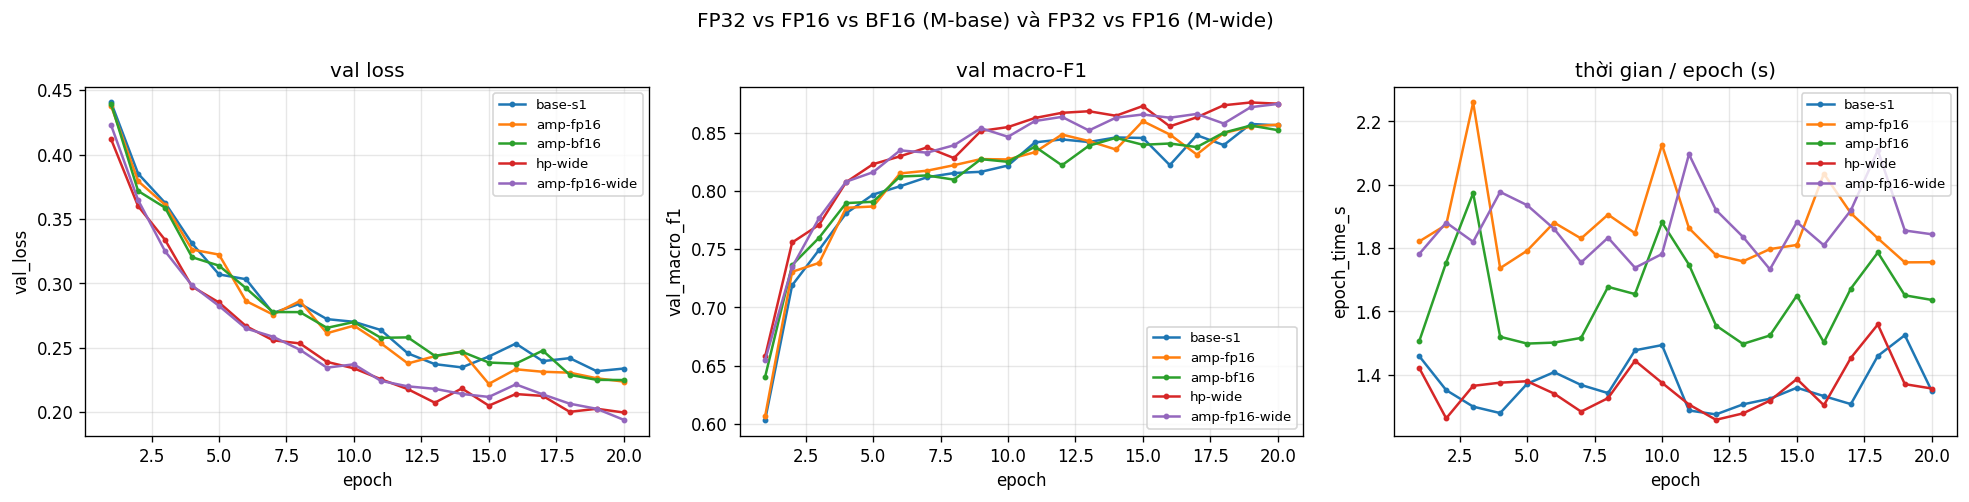

compare_arch.png


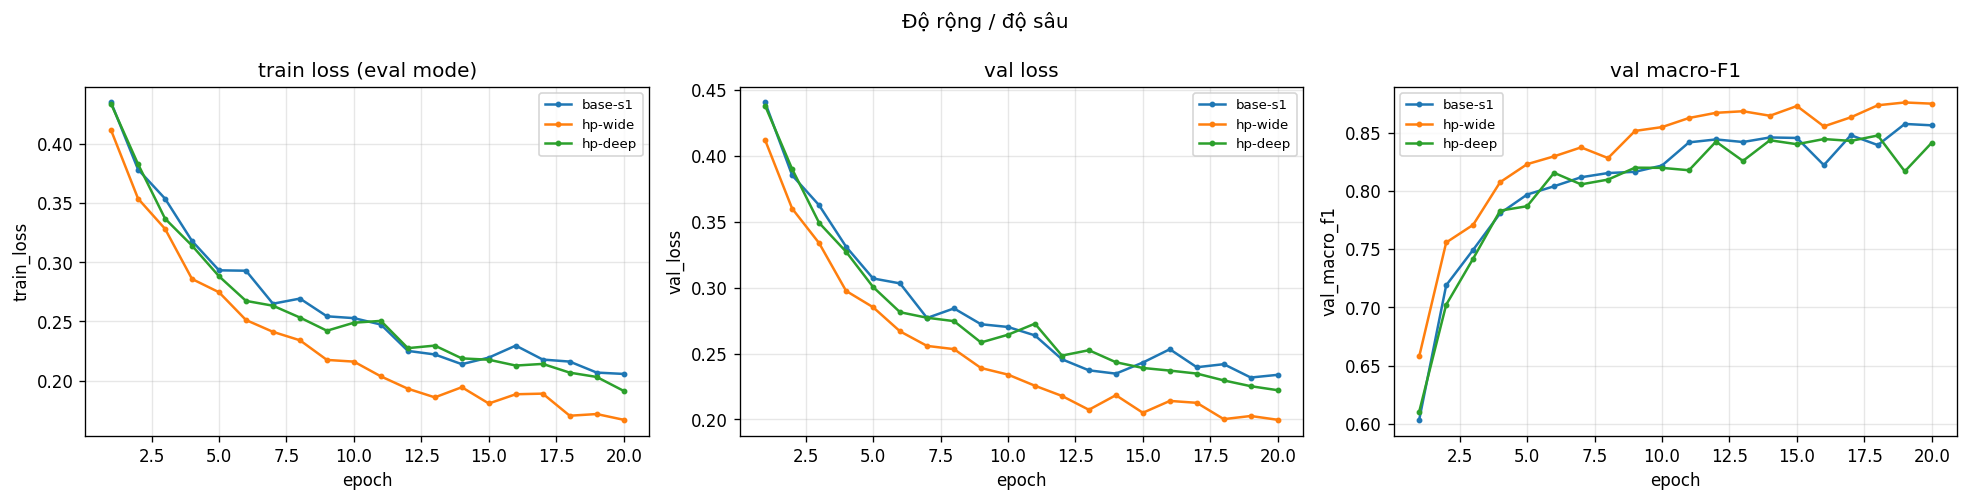

compare_baseline_seeds.png


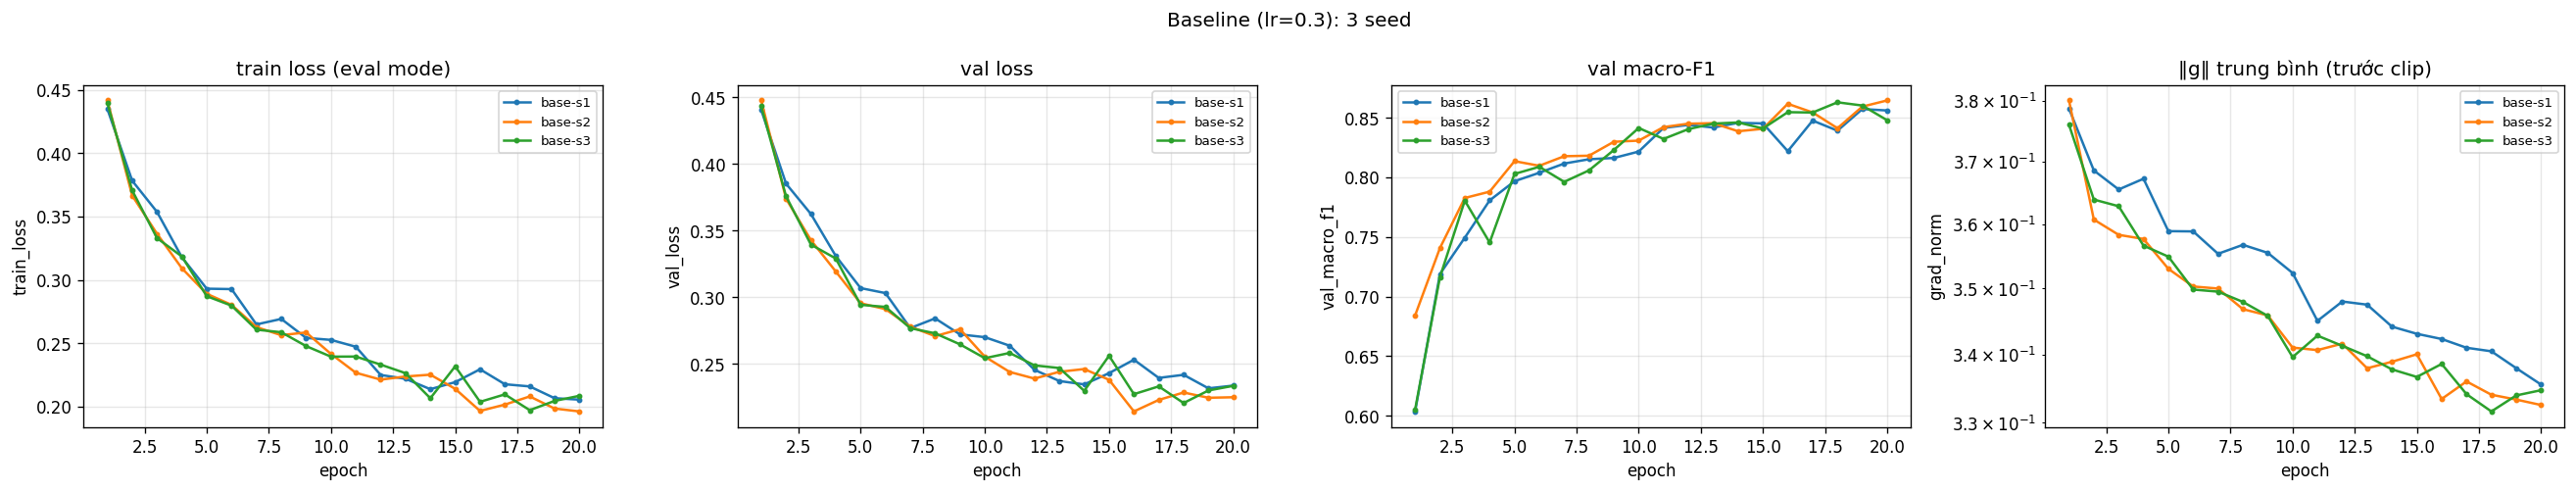

compare_batch.png


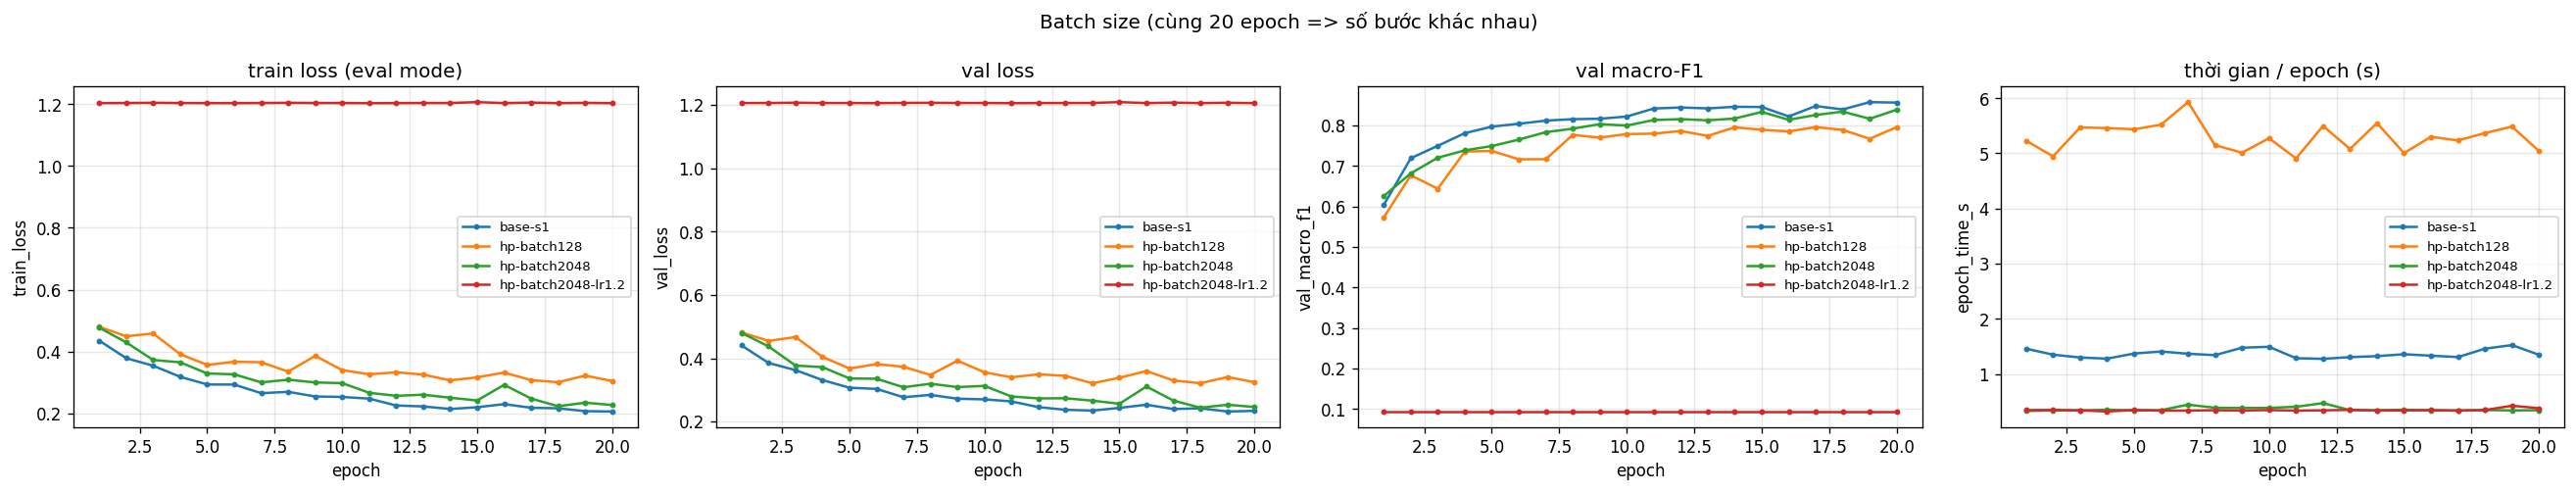

compare_clipping.png


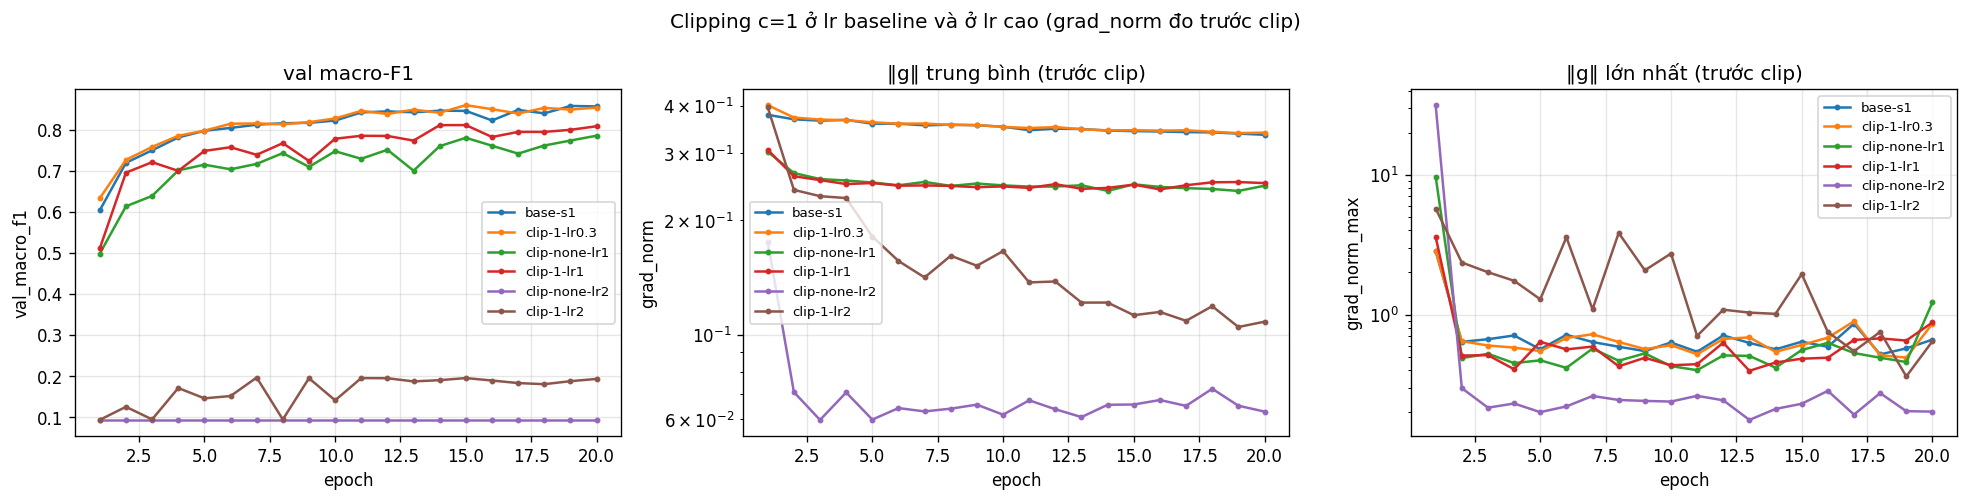

compare_dropout.png


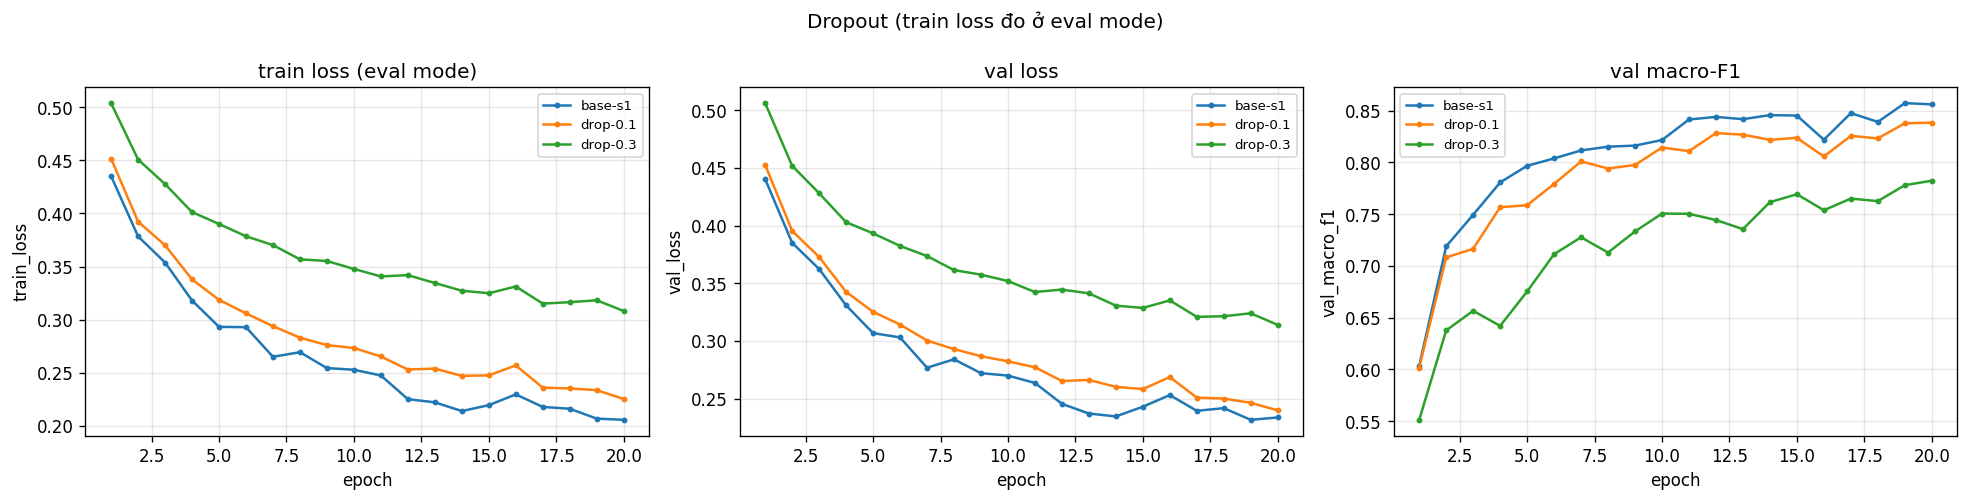

compare_init.png


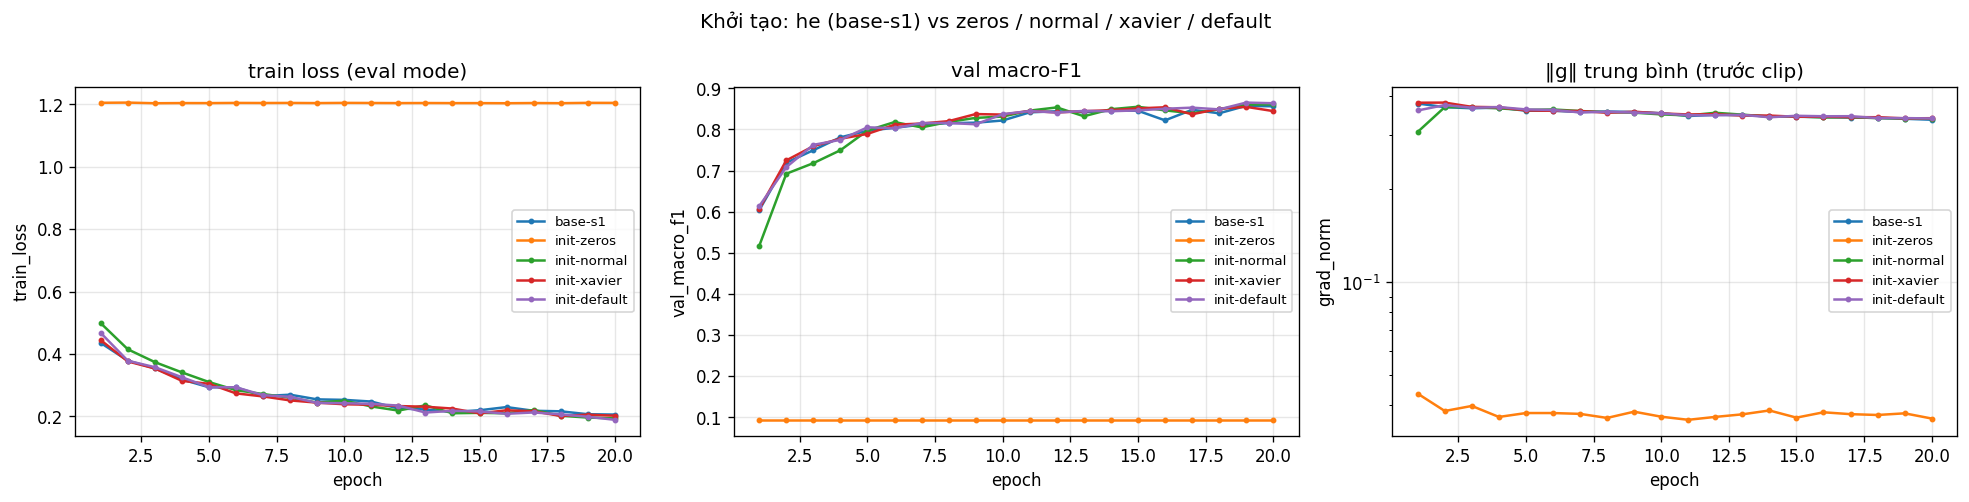

compare_loss.png


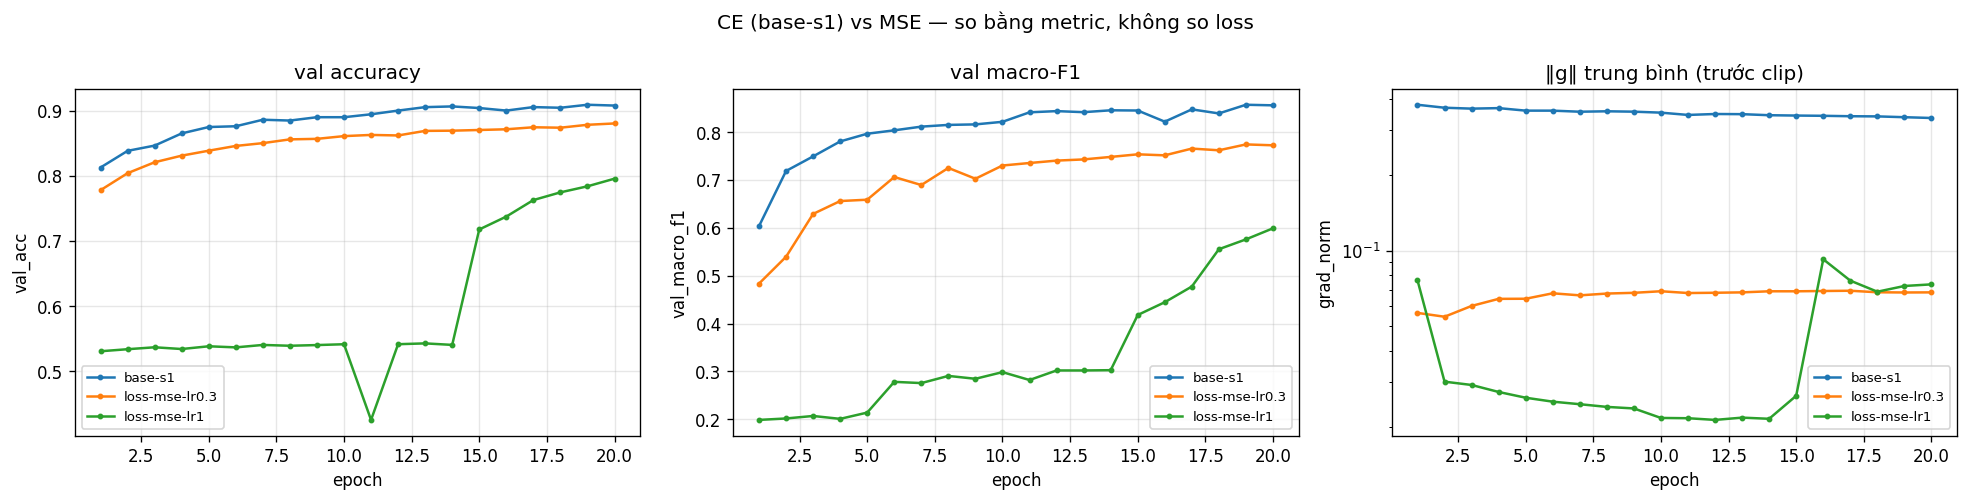

compare_lr.png


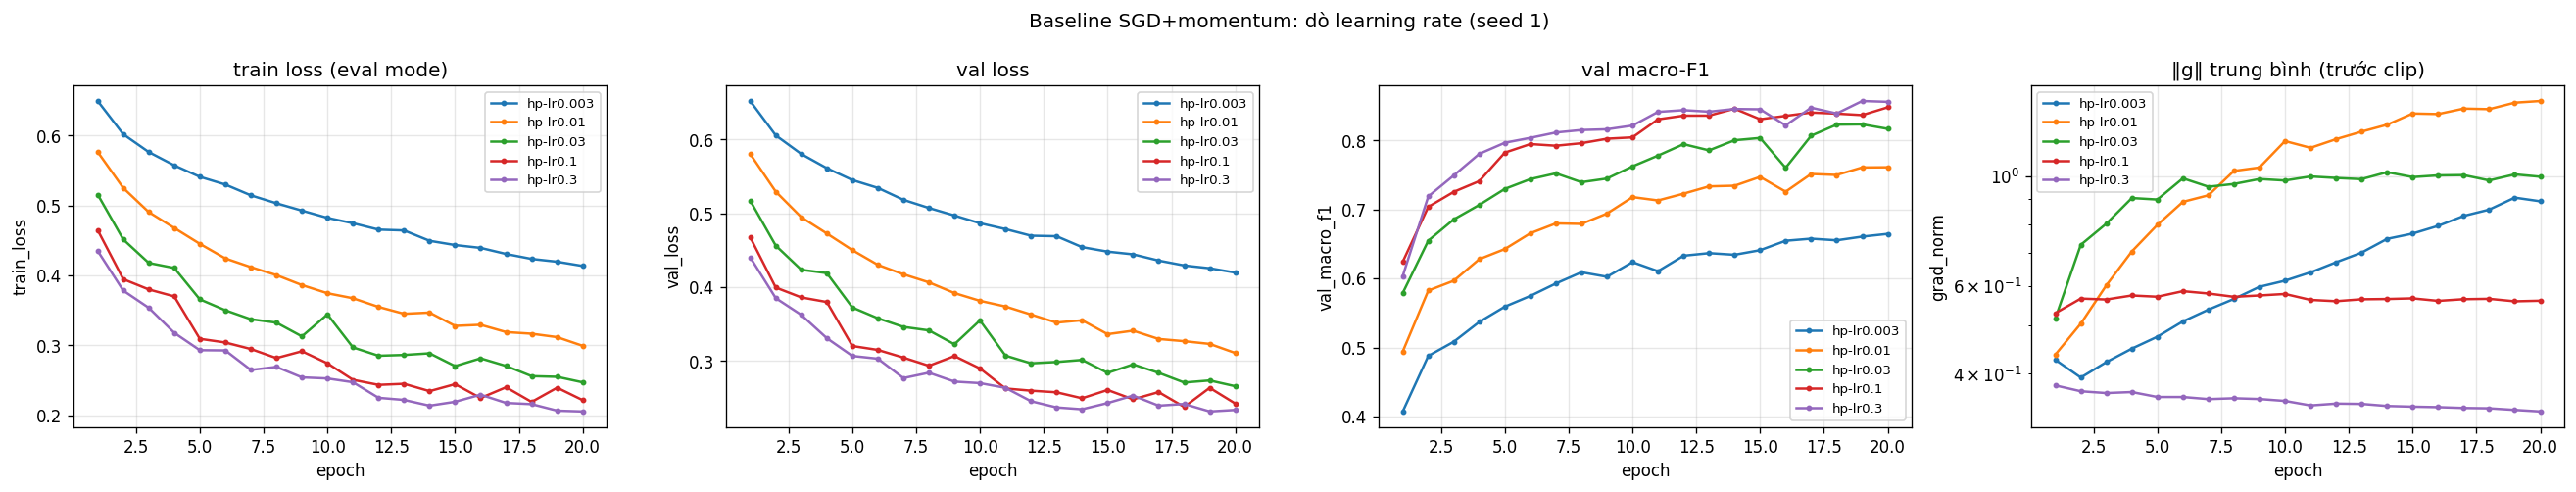

compare_optimizer.png


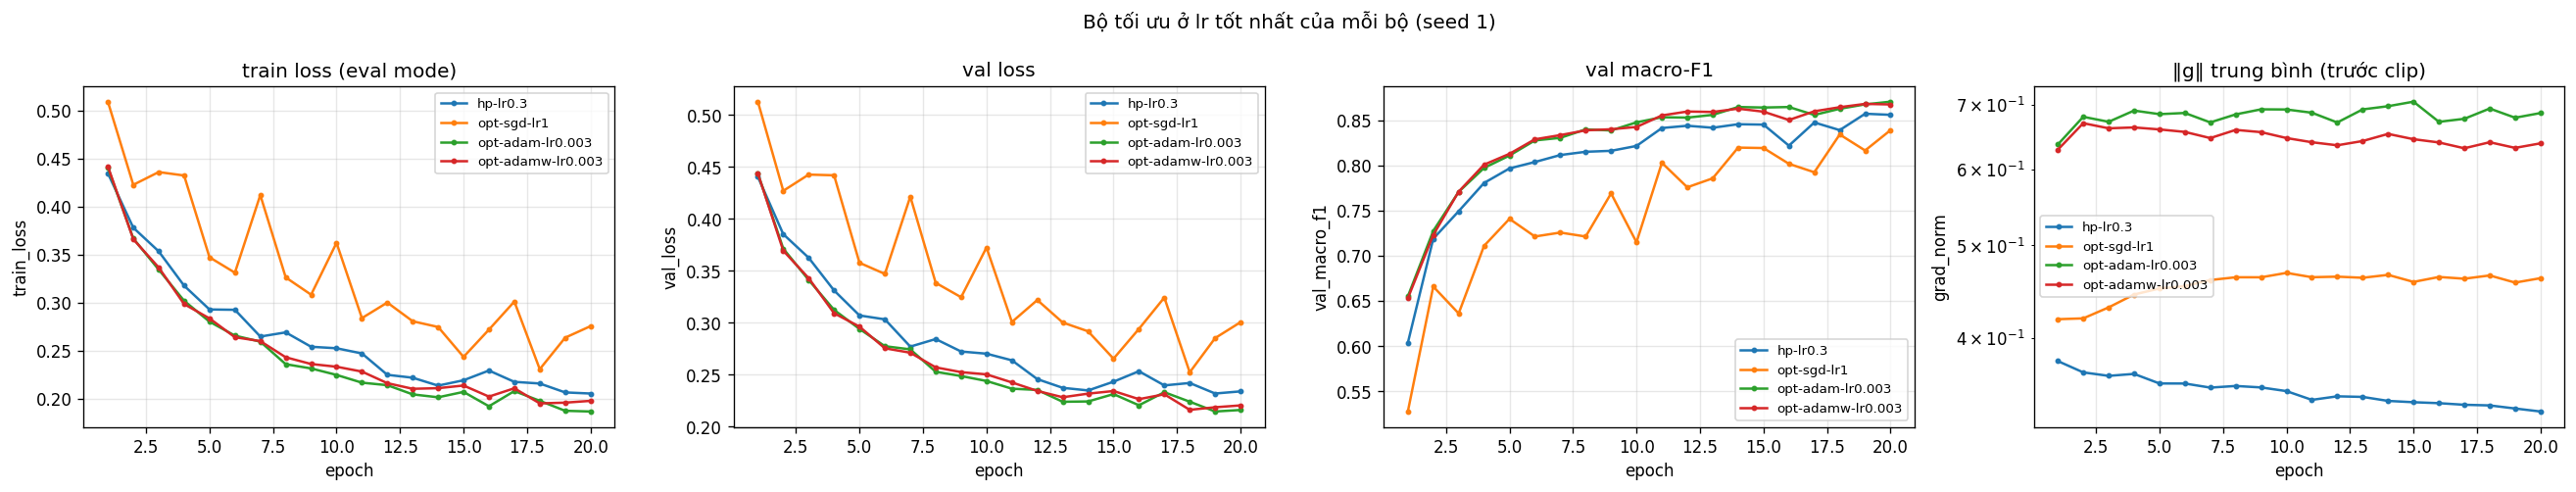

compare_schedule.png


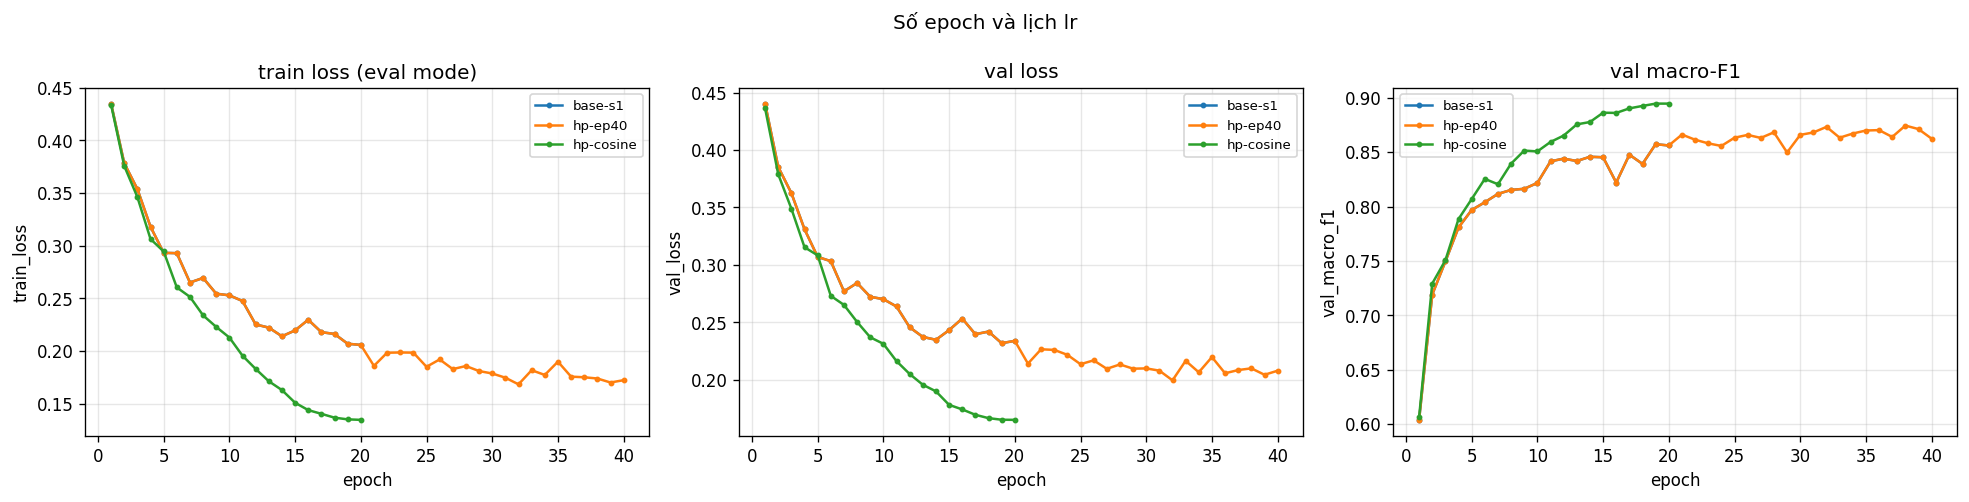

In [ ]:
# Hiển thị các ảnh so sánh theo nhóm (để output notebook giữ lại bằng chứng)
from IPython.display import Image
import glob
for f in sorted(glob.glob(f"{OUT_DIR}/figures/compare_*.png")):
    print(os.path.basename(f)); display(Image(filename=f))

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** cấu hình đã chốt **chỉ bằng val** ở 3.8 → nạp trọng số của epoch có val loss thấp nhất → dự đoán trên **toàn bộ** eval ở `eval()` → ghi CSV `row_id,pred` → chấm bằng đúng `scripts/evaluate.py` (accuracy và **macro-F1**).
Chỉ làm cho hai mô hình, mỗi mô hình một lần:

| vai trò | exp_id | seed | file dự đoán | file kết quả |
|---|---|---|---|---|
| baseline | `base-s1` | 1 | `predictions_eval_baseline.csv` (để đối chiếu, không phải file nộp chính) | `eval_result_baseline.json` |
| **cấu hình cuối cùng (nộp)** | `fin-wide-cos-ep40` | 1 | **`predictions_eval.csv`** | **`eval_result.json`** |

Trọng số chỉ nằm trong bộ nhớ (`best_state`, không ghi ra JSON). Nếu kernel đã khởi động lại hoặc kết quả được nạp lại từ JSON, ô dưới chạy lại đúng cấu hình đó (seed cố định nên kết quả trùng, có `assert` kiểm tra). Điểm eval **không được dùng để đổi bất kỳ lựa chọn nào** ở trên.

In [ ]:
EVAL_PLAN = {"baseline": ("base-s1", "predictions_eval_baseline.csv", "eval_result_baseline.json"),
             "final":    (FINAL_ID,  "predictions_eval.csv",          "eval_result.json")}
EVAL = {}
for role, (eid, csv_name, json_name) in EVAL_PLAN.items():
    r = RESULTS[eid]
    if r.get("best_state") is None:                      # kết quả nạp lại từ JSON: chạy lại để có trọng số
        f1_saved = r["summary"]["val_macro_f1"]
        r = run({**r["cfg"]}, reuse=False)
        assert abs(r["summary"]["val_macro_f1"] - f1_saved) < 1e-9, "chạy lại không tái lập được kết quả val"
    csv_path, json_path = os.path.abspath(f"{OUT_DIR}/{csv_name}"), os.path.abspath(f"{OUT_DIR}/{json_name}")
    final_eval(r["cfg"], r, data, csv_path)
    proc = subprocess.run([sys.executable, "scripts/evaluate.py", "--pred", csv_path, "--out", json_path],
                          cwd=REPO_ROOT, capture_output=True, text=True, encoding="utf-8",
                          env={**os.environ, "PYTHONIOENCODING": "utf-8"})
    print(f"===== {role}: {eid} (seed {r['cfg']['seed']}, best epoch {r['summary']['best_epoch']}) =====")
    print(proc.stdout)
    assert proc.returncode == 0, proc.stdout + proc.stderr
    EVAL[role] = json.load(open(json_path, encoding="utf-8"))

cmp_eval = pd.DataFrame([
    {"vai trò": role, "exp_id": eid, "seed": RESULTS[eid]["cfg"]["seed"], "best_epoch": RESULTS[eid]["summary"]["best_epoch"],
     "val_acc": RESULTS[eid]["summary"]["val_acc"], "val_macro_f1": RESULTS[eid]["summary"]["val_macro_f1"],
     "eval_acc": EVAL[role]["accuracy"], "eval_macro_f1": EVAL[role]["macro_f1"],
     "eval − val (F1)": EVAL[role]["macro_f1"] - RESULTS[eid]["summary"]["val_macro_f1"]}
    for role, (eid, _, _) in EVAL_PLAN.items()]).set_index("vai trò")
display(cmp_eval.round(4))
d = EVAL["final"]["macro_f1"] - EVAL["baseline"]["macro_f1"]
print(f"cải thiện eval macro-F1 (cuối − baseline) = {d:+.4f}  | 2σ_seed (đo trên val) = {F1_2SIGMA:.4f}")

đã ghi 116203 dự đoán của base-s1 (best_epoch = 19) -> /content/K4-Track4-Day1-Neuralnetwork/submission_2A202602451/predictions_eval_baseline.csv
===== baseline: base-s1 (seed 1, best epoch 19) =====
n_eval = 116203
accuracy = 0.9089
macro_f1 = 0.8565   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9304  0.8798  0.9044
  1    56661     0.9025  0.9514  0.9263
  2     7151     0.9303  0.8610  0.8943
  3      549     0.8330  0.7723  0.8015
  4     1899     0.8195  0.7077  0.7595
  5     3473     0.7670  0.8557  0.8089
  6     4102     0.9405  0.8632  0.9002

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  37274   4837     1    0    44     9   203
1   2225  53908    87    0   237   183    21
2     13    271  6157   67    14   629     0
3      0      0    57  424     0    68     0
4     26    494    21    0  1344    14     0
5     17    170   295   18     1  2972     0
6    506     55     0    0     0     0  3541

đã

,exp_id,seed,best_epoch,val_acc,val_macro_f1,eval_acc,eval_macro_f1,eval − val (F1)
vai trò,,,,,,,,
baseline,base-s1,1,19,0.9090,0.8573,0.9089,0.8565,-0.0009
final,fin-wide-cos-ep40,1,40,0.9543,0.9232,0.9551,0.9264,0.0032


cải thiện eval macro-F1 (cuối − baseline) = +0.0699  | 2σ_seed (đo trên val) = 0.0060


### 4.1 Phân tích lỗi theo lớp
Số liệu lấy từ `per_class` và `confusion_matrix` trong hai file JSON (hàng = nhãn thật, cột = dự đoán). Ma trận được chuẩn hoá theo hàng (tỉ lệ % của mỗi nhãn thật) để so được các lớp có kích thước rất khác nhau.
Để lý giải bằng dữ liệu, so sánh lớp khó nhất với lớp nó hay bị nhầm thành nhất: số mẫu train, trung bình (đã chuẩn hoá, đơn vị σ) của 10 đặc trưng số, và phân bố khu vực hoang dã (Wilderness_Area).

,support,train_n,precision_base,recall_base,f1_base,precision_final,recall_final,f1_final,ΔF1
0 Spruce/Fir,42368,135578,0.9304,0.8798,0.9044,0.9560,0.9515,0.9537,0.0493
1 Lodgepole,56661,181312,0.9025,0.9514,0.9263,0.9597,0.9646,0.9622,0.0359
2 Ponderosa,7151,22882,0.9303,0.8610,0.8943,0.9509,0.9515,0.9512,0.0569
3 Cottonwood,549,1759,0.8330,0.7723,0.8015,0.8851,0.8415,0.8627,0.0612
4 Aspen,1899,6075,0.8195,0.7077,0.7595,0.8900,0.8731,0.8814,0.1219
5 Douglas-fir,3473,11115,0.7670,0.8557,0.8089,0.9146,0.9093,0.9119,0.1030
6 Krummholz,4102,13126,0.9405,0.8632,0.9002,0.9628,0.9603,0.9616,0.0613


Ma trận nhầm lẫn của cấu hình cuối (hàng = thật, cột = dự đoán):


,0,1,2,3,4,5,6
0 Spruce/Fir,40313,1896,0,0,21,2,136
1 Lodgepole,1689,54656,69,0,167,64,16
2 Ponderosa,1,97,6804,40,13,196,0
3 Cottonwood,0,0,63,462,0,24,0
4 Aspen,27,192,13,0,1658,9,0
5 Douglas-fir,4,82,206,20,3,3158,0
6 Krummholz,135,27,0,0,1,0,3939



Lớp khó nhất (F1 thấp nhất, cấu hình cuối): 3 Cottonwood, F1 = 0.8627, precision = 0.8851, recall = 0.8415
  549 mẫu thật: đúng 462, bị đoán thành 2 Ponderosa 63 mẫu (11.5%); các nhầm khác: 5:24
  60 mẫu lớp khác bị đoán nhầm thành 3 Cottonwood, nhiều nhất từ 2 Ponderosa (40)

Trung bình 10 đặc trưng số (đơn vị σ của train) — 3 Cottonwood vs 2 Ponderosa:


,TB 3 Cottonwood,TB 2 Ponderosa,chênh (σ)
Elevation,-2.626,-2.018,-0.608
Aspect,-0.173,0.182,-0.355
Slope,0.604,0.887,-0.282
Horizontal_Distance_To_Hydrology,-0.770,-0.273,-0.497
Vertical_Distance_To_Hydrology,-0.102,0.281,-0.383
Horizontal_Distance_To_Roadways,-0.921,-0.903,-0.018
Hillshade_9am,0.626,-0.377,1.003
Hillshade_Noon,-0.337,-0.380,0.043
Hillshade_3pm,-0.843,-0.060,-0.783
Horizontal_Distance_To_Fire_Points,-0.851,-0.805,-0.046


Tỉ lệ mẫu thuộc từng Wilderness_Area:


,3 Cottonwood,2 Ponderosa
Wilderness_Area_0,0.0,0.000
Wilderness_Area_1,0.0,0.000
Wilderness_Area_2,0.0,0.398
Wilderness_Area_3,1.0,0.602


Elevation: 90% mẫu 3 Cottonwood nằm trong [-3.24, -2.09]σ; 39.4% mẫu 2 Ponderosa cũng rơi vào khoảng đó


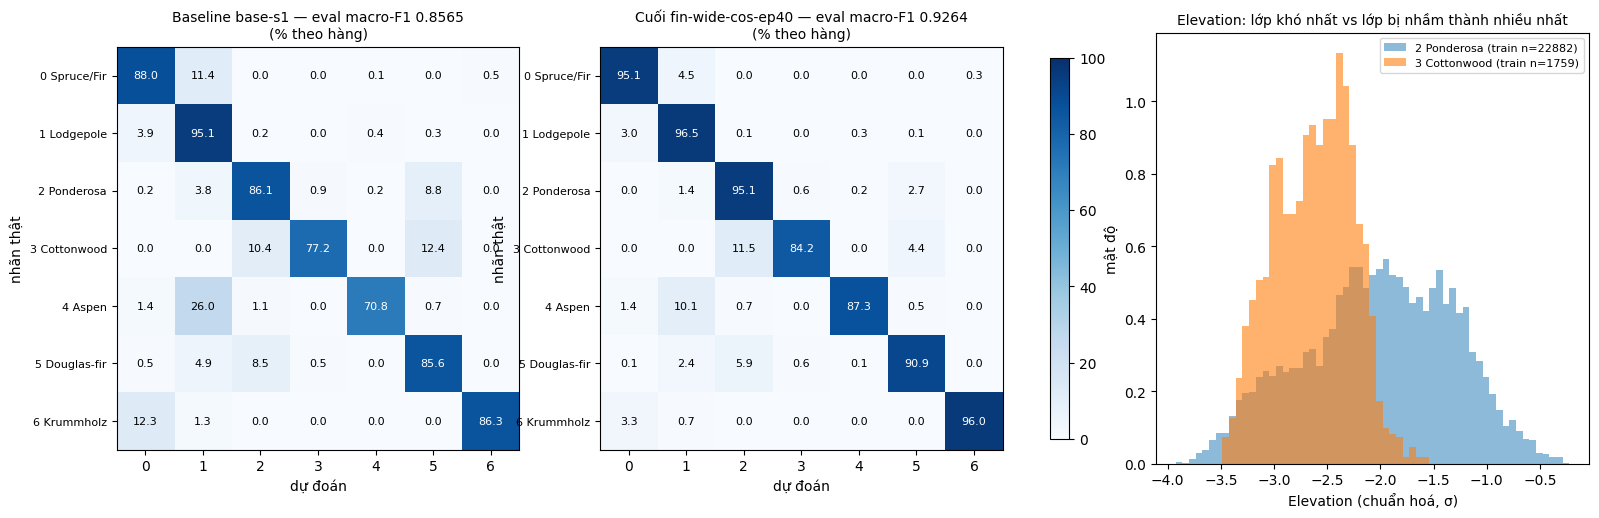

In [ ]:
import matplotlib.pyplot as plt
names = ["0 Spruce/Fir", "1 Lodgepole", "2 Ponderosa", "3 Cottonwood", "4 Aspen", "5 Douglas-fir", "6 Krummholz"]
pc = pd.DataFrame({
    "support": [c["support"] for c in EVAL["final"]["per_class"]],
    "train_n": torch.bincount(data["y_tr"], minlength=7).cpu().numpy(),
    **{f"{m}_base": [c[m] for c in EVAL["baseline"]["per_class"]] for m in ("precision", "recall", "f1")},
    **{f"{m}_final": [c[m] for c in EVAL["final"]["per_class"]] for m in ("precision", "recall", "f1")},
}, index=names)
pc["ΔF1"] = pc["f1_final"] - pc["f1_base"]
display(pc.round(4))

cms = {k: np.array(EVAL[k]["confusion_matrix"]) for k in ("baseline", "final")}
cm_pct = {k: 100 * v / v.sum(axis=1, keepdims=True) for k, v in cms.items()}
print("Ma trận nhầm lẫn của cấu hình cuối (hàng = thật, cột = dự đoán):")
display(pd.DataFrame(cms["final"], index=names, columns=[n.split()[0] for n in names]))

f1_final = pc["f1_final"].to_numpy()
hard = int(f1_final.argmin())
off = cms["final"][hard].copy(); off[hard] = 0
conf_with = int(off.argmax())
# lớp nào "hút" nhiều mẫu của lớp khác nhất (nhầm thành lớp hard)
col = cms["final"][:, hard].copy(); col[hard] = 0
print(f"\nLớp khó nhất (F1 thấp nhất, cấu hình cuối): {names[hard]}, F1 = {f1_final[hard]:.4f}, "
      f"precision = {pc['precision_final'].iloc[hard]:.4f}, recall = {pc['recall_final'].iloc[hard]:.4f}")
print(f"  {cms['final'][hard].sum()} mẫu thật: đúng {cms['final'][hard, hard]}, bị đoán thành {names[conf_with]} "
      f"{off[conf_with]} mẫu ({100 * off[conf_with] / cms['final'][hard].sum():.1f}%); các nhầm khác: "
      + ", ".join(f"{names[j].split()[0]}:{off[j]}" for j in np.argsort(-off) if off[j] > 0 and j != conf_with))
print(f"  {col.sum()} mẫu lớp khác bị đoán nhầm thành {names[hard]}, nhiều nhất từ {names[int(col.argmax())]} ({col.max()})")

# Đặc trưng: so lớp khó nhất với lớp nó bị nhầm thành nhiều nhất (trên TRAIN đã chuẩn hoá, không dùng eval)
feat_names = list(np.load(f"{REPO_ROOT}/data/processed/train.npz")["feature_names"])
Xtr, ytr = data["X_tr"].cpu().numpy(), data["y_tr"].cpu().numpy()
A, B = Xtr[ytr == hard], Xtr[ytr == conf_with]
feat = pd.DataFrame({f"TB {names[hard]}": A[:, :10].mean(0), f"TB {names[conf_with]}": B[:, :10].mean(0),
                     "chênh (σ)": A[:, :10].mean(0) - B[:, :10].mean(0)}, index=feat_names[:10])
print(f"\nTrung bình 10 đặc trưng số (đơn vị σ của train) — {names[hard]} vs {names[conf_with]}:")
display(feat.round(3))
wild = pd.DataFrame({names[hard]: A[:, 10:14].mean(0), names[conf_with]: B[:, 10:14].mean(0)}, index=feat_names[10:14])
print("Tỉ lệ mẫu thuộc từng Wilderness_Area:")
display(wild.round(3))
lo, hi = np.percentile(A[:, 0], [5, 95])
print(f"Elevation: 90% mẫu {names[hard]} nằm trong [{lo:.2f}, {hi:.2f}]σ; "
      f"{100 * np.mean((B[:, 0] >= lo) & (B[:, 0] <= hi)):.1f}% mẫu {names[conf_with]} cũng rơi vào khoảng đó")

fig, axes = plt.subplots(1, 3, figsize=(19, 5.6))
for ax, k, title in [(axes[0], "baseline", f"Baseline base-s1 — eval macro-F1 {EVAL['baseline']['macro_f1']:.4f}"),
                     (axes[1], "final", f"Cuối {FINAL_ID} — eval macro-F1 {EVAL['final']['macro_f1']:.4f}")]:
    im = ax.imshow(cm_pct[k], cmap="Blues", vmin=0, vmax=100)
    for i in range(7):
        for j in range(7):
            ax.text(j, i, f"{cm_pct[k][i, j]:.1f}", ha="center", va="center", fontsize=8,
                    color="white" if cm_pct[k][i, j] > 60 else "black")
    ax.set_xticks(range(7)); ax.set_yticks(range(7)); ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel("dự đoán"); ax.set_ylabel("nhãn thật"); ax.set_title(title + "\n(% theo hàng)", fontsize=10)
fig.colorbar(im, ax=axes[:2], fraction=0.02)
ax = axes[2]
bins = np.linspace(min(A[:, 0].min(), B[:, 0].min()), max(A[:, 0].max(), B[:, 0].max()), 60)
ax.hist(B[:, 0], bins=bins, alpha=0.5, density=True, label=f"{names[conf_with]} (train n={len(B)})")
ax.hist(A[:, 0], bins=bins, alpha=0.6, density=True, label=f"{names[hard]} (train n={len(A)})")
ax.set_xlabel("Elevation (chuẩn hoá, σ)"); ax.set_ylabel("mật độ"); ax.legend(fontsize=8)
ax.set_title(f"Elevation: lớp khó nhất vs lớp bị nhầm thành nhiều nhất", fontsize=10)
fig.savefig(f"{OUT_DIR}/figures/compare_eval_confusion.png", dpi=120, bbox_inches="tight")
plt.show()

**Phân tích lỗi:**
- **Eval:** cấu hình cuối `fin-wide-cos-ep40` (seed 1) đạt macro-F1 **0,9264**, acc 0,9551; baseline `base-s1` đạt 0,8565, acc 0,9089. Cải thiện +0,070. Val và eval lệch rất ít (−0,0009 và +0,0032), nên val là ước lượng đáng tin.
- **Lớp khó nhất (đo được):** **3 Cottonwood/Willow**, F1 = 0,8627 (precision 0,885, recall 0,842). Trong 549 mẫu thật, 63 mẫu (11,5%) bị đoán thành **2 Ponderosa Pine** và 24 mẫu thành 5 Douglas-fir. Ngược lại, 60 mẫu lớp khác bị đoán thành lớp 3, chủ yếu từ Ponderosa (40). Về số lượng tuyệt đối, cặp nhầm lớn nhất là 0 ↔ 1 (1 896 + 1 689 mẫu), nhưng hai lớp này rất lớn nên F1 vẫn > 0,95. Ở baseline, lớp khó nhất là 4 Aspen (0,7595); cấu hình cuối cải thiện Aspen (+0,12) và Douglas-fir (+0,10) nhiều nhất.
- **Dữ liệu (train):** lớp 3 chỉ có 1 759 mẫu train, ít hơn Ponderosa 13 lần. 100% Cottonwood ở Wilderness_Area_3 (Ponderosa: 60%). Cả hai đều ở độ cao rất thấp (Elevation −2,63σ và −2,02σ); 39% mẫu Ponderosa nằm trong khoảng Elevation chứa 90% mẫu Cottonwood. Các đặc trưng tách được hai lớp là Hillshade_9am (+1,0σ), Hillshade_3pm (−0,78σ) và khoảng cách tới nguồn nước (−0,50σ, hợp với việc Cottonwood/Willow là loài ven sông).
- **Giả thuyết (chưa kiểm chứng):** lớp 3 vừa hiếm vừa chồng lấn với Ponderosa ở hai đặc trưng mạnh nhất. CE không trọng số ưu tiên lớp lớn hơn trong vùng chồng lấn, nên ranh giới bị kéo về phía Ponderosa. Cách sẽ thử: CE có trọng số theo tần suất lớp hoặc lấy mẫu lại lớp hiếm, chọn bằng val macro-F1. Mình chưa chạy thí nghiệm này.

### 4.2 Bảng `experiments.xlsx`
Mỗi lần chạy (mỗi file `results/<exp_id>.json`) là một dòng, theo thứ tự các mục của notebook. `eval_acc` / `eval_macro_f1` chỉ điền cho `base-s1` và cấu hình cuối, lấy nguyên từ hai file JSON của `evaluate.py`. Sheet Seeds: `base-s1..3`. Sheet Summary: nhận xét ngắn theo nhóm. Các cột công thức của mẫu giữ nguyên (Excel/LibreOffice tính lại khi mở).

In [ ]:
# Đảm bảo dùng results_table.py mới nhất: trên Colab, kéo code mới về (runtime có thể còn bản cũ),
# rồi nạp lại module (kernel đã import bản cũ thì Python vẫn giữ bản đó trong bộ nhớ)
import importlib, results_table
if IN_COLAB:
    pull = subprocess.run(["git", "-C", COLAB_REPO, "pull", "--rebase"], capture_output=True, text=True)
    print("git pull:", (pull.stdout + pull.stderr).strip())
assert "NotImplementedError" not in open(results_table.__file__, encoding="utf-8").read(),     "results_table.py vẫn là bản cũ: kiểm tra output git pull ở trên"
importlib.reload(results_table)
from results_table import load_results, to_row, write_xlsx

order = (base_ids + lr_ids + loss_ids + [i for k, v in opt_ids.items() if k != "sgd_momentum" for i in v]
         + hp_ids + drop_ids + clip_ids + amp_ids + init_ids + fin_ids + final_seed_ids[1:])
saved = {r["cfg"]["exp_id"]: r for r in load_results(f"{OUT_DIR}/results")}
assert set(order) == set(saved), f"lệch giữa danh sách và results/: {set(order) ^ set(saved)}"
assert len(order) == len(set(order))

extra_notes = {
    "base-s1": "baseline, seed 1; trùng cấu hình hp-lr0.3 (kết quả tái lập y hệt)",
    "base-s2": "baseline, seed 2", "base-s3": "baseline, seed 3",
    "hp-lr0.3": "lr được chọn cho baseline (val macro-F1 cao nhất trong lưới)",
    "hp-batch2048-lr1.2": "sụp: luôn đoán lớp đa số sau gai gradient đầu (loss không NaN)",
    "clip-none-lr2": "sụp: luôn đoán lớp đa số từ epoch 2 (ReLU chết, loss không NaN)",
    "init-zeros": "đối xứng không phá được: chỉ b3 có gradient, luôn đoán lớp đa số",
    "amp-bf16": "T4 (CC 7.5) không có BF16 phần cứng; PyTorch giả lập",
    FINAL_ID: f"CẤU HÌNH CUỐI CÙNG (chọn bằng val ở 3.8), seed 1 = mô hình nộp, best_epoch {RESULTS[FINAL_ID]['summary']['best_epoch']}",
}
eval_rows = {"base-s1": EVAL["baseline"], FINAL_ID: EVAL["final"]}
rows = [to_row(saved[i], eval_rows.get(i), extra_notes.get(i, "")) for i in order]

# mỗi dòng phải có đúng một ảnh figures/<exp_id>.png
import glob
figs = {os.path.basename(f)[:-4] for f in glob.glob(f"{OUT_DIR}/figures/*.png") if not os.path.basename(f).startswith("compare_")}
assert figs == set(order), f"ảnh và bảng lệch nhau: {figs ^ set(order)}"

summary_notes = {
    "baseline": "SGD+momentum lr 0.3, 3 seed: val macro-F1 0.8607 ± 0.0030 (2σ = 0.006); còn giảm nhẹ ở epoch 20, chưa quá khớp.",
    "loss": "MSE kém CE rõ (-0.088 ở lr tốt nhất của MSE); thiệt chủ yếu ở lớp hiếm; lr 1.0 còn tệ hơn.",
    "optimizer": "Ở lr tốt nhất: Adam 0.8677 ≈ AdamW 0.8646 ≈ SGDM 0.8573 (chênh sát 2σ, 1 seed); SGD thuần kém rõ (0.8344).",
    "hparam": "Cosine +0.034 (lớn nhất), M-wide +0.014, 40 epoch +0.013; batch 128 với cùng lr kém (-0.066); batch 2048 + lr x4 sụp.",
    "dropout": "q 0.1 và 0.3 đều kém (-0.022, -0.078): baseline chưa quá khớp, dropout chỉ làm train loss tăng.",
    "clipping": "Ở lr 0.3 clip c=1 gần như không kích hoạt (không khác). Ở lr 1 clip giúp +0.037; ở lr 2 không clip sụp, có clip vẫn kém.",
    "amp": "FP16 ≈ FP32 về metric nhưng chậm hơn ~32% trên T4 (mạng nhỏ, chi phí ép kiểu + GradScaler); BF16 giả lập chậm hơn ~15%.",
    "init": "zeros: chỉ b3 học, luôn đoán lớp đa số. normal/xavier/default ≈ He sau 20 epoch (mạng 3 lớp chưa đủ sâu để khác).",
    "final": f"{FINAL_ID}: M-wide + cosine + 40 epoch, 3 seed val macro-F1 {FINAL_F1_MEAN:.4f} ± {FINAL_F1_STD:.4f} (+{FINAL_F1_MEAN - BASE_F1:.3f} so với baseline).",
}
xlsx_path = f"{OUT_DIR}/experiments.xlsx"
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", xlsx_path,
           seed_ids=base_ids, summary_notes=summary_notes)

# đọc lại để kiểm tra
import openpyxl
ws = openpyxl.load_workbook(xlsx_path)["Experiments"]
hdr = [c.value for c in ws[1]]
back = pd.DataFrame([[c.value for c in r] for r in ws.iter_rows(min_row=2, max_row=len(rows) + 1)], columns=hdr)
print(f"{len(rows)} dòng, {len(figs)} ảnh <exp_id>.png; sheet: {openpyxl.load_workbook(xlsx_path).sheetnames}")
display(back[["exp_id", "group", "optimizer", "lr", "batch", "epochs", "hidden", "best_epoch", "val_acc", "val_macro_f1",
              "eval_acc", "eval_macro_f1", "diverged"]].set_index("exp_id"))
for eid, role in [("base-s1", "baseline"), (FINAL_ID, "final")]:
    rr = back.set_index("exp_id").loc[eid]
    assert abs(rr["eval_macro_f1"] - EVAL[role]["macro_f1"]) < 5e-4 and abs(rr["eval_acc"] - EVAL[role]["accuracy"]) < 5e-4
print("eval trong bảng khớp eval_result*.json ✓")

NotImplementedError: 

In [ ]:
# Kiểm tra trước khi nộp
sub = os.path.abspath(OUT_DIR)
required = ["experiments.xlsx", "predictions_eval.csv", "eval_result.json", "figures", "code/lab.ipynb"]
for f in required:
    print(f"{'✓' if os.path.exists(os.path.join(sub, f)) else '✗'} {f}")
print("REPORT.md:", "✓" if os.path.exists(os.path.join(sub, "REPORT.md")) else "chưa có (viết sau khi có số eval)")
left = [f for f in glob.glob(os.path.join(sub, "code", "*.py")) if "NotImplementedError" in open(f, encoding="utf-8").read()]
print("file .py còn NotImplementedError:", left or "không")
bad = [f for f in glob.glob(os.path.join(sub, "**", "*"), recursive=True) if f.endswith((".pt", ".pth", ".ckpt", ".npz"))]
print("file trọng số/dữ liệu trong thư mục nộp:", bad or "không")

# Colab: đẩy toàn bộ kết quả về GitHub nếu đã đặt GH_TOKEN (không bao giờ dừng chờ nhập)
if IN_COLAB:
    push_outputs("Part 4: eval, experiments.xlsx, figures, results")